In [11]:
import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import jax.numpy as jnp
import jax

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import time
import datetime
import functools

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

In [12]:
# ============================
# 1. SIMULATE MIXTURE DATA
# ============================

def generate_mixture_simulated_data(n_units=300, n_obs=50, n_components=1, seed=42):
    """Generates synthetic HMNL choice data drawn from a mixture of normals."""
    np.random.seed(seed)
    
    n_alts = 4
    n_params = 4  
    n_demos = 2   
    
    # A. Generate Demographic Data (Z)
    Z = np.column_stack([np.ones(n_units), np.random.normal(0, 1, n_units)])
    
    # B. Define True Mixture Parameters
    pi_true = np.array([0.6, 0.4]) if n_components == 2 else np.ones(n_components)/n_components
    
    # Delta (Global params) shape: (K, n_demos, n_params)
    Delta_true = np.zeros((n_components, n_demos, n_params))
    
    # Component 0: Strong preference for Brand 1
    Delta_true[0] = np.array([
        [ 2.5, -0.5, -0.5, -2.0],  
        [ 0.8, -0.3,  0.0,  0.5]   
    ])
    
    if n_components > 1:
        # Component 1: Strong preference for Brand 3, less price sensitive
        Delta_true[1] = np.array([
            [-1.5, -0.5,  2.5, -0.5],  
            [-0.5,  0.2,  0.5, -0.1]   
        ])
    
    # Sigma (Variances) shape: (K, n_params, n_params)
    Sigma_true = np.stack([np.diag([1, 0.5, 1.5, 0.5])] * n_components)
    
    # C. Generate Individual Parameters
    beta_true = np.zeros((n_units, n_params))
    component_assignments = np.random.choice(n_components, size=n_units, p=pi_true)
    
    for i in range(n_units):
        k = component_assignments[i]
        mu_i = Z[i] @ Delta_true[k]
        beta_true[i] = np.random.multivariate_normal(mu_i, Sigma_true[k])
        
    # D. Simulate Choices
    X_list, y_list, unit_idx_list = [], [], []
    for i in range(n_units):
        for t in range(n_obs):
            X_it = np.zeros((n_alts, n_params))
            X_it[1, 0] = 1.0; X_it[2, 1] = 1.0; X_it[3, 2] = 1.0
            X_it[:, 3] = np.random.uniform(1.0, 5.0, n_alts)
            
            U_it = X_it @ beta_true[i]
            probs = np.exp(U_it) / np.sum(np.exp(U_it))
            y_it = np.random.choice(n_alts, p=probs)
            
            X_list.append(X_it); y_list.append(y_it); unit_idx_list.append(i)
            
    return {
        "X": jnp.array(X_list), "y": jnp.array(y_list), "Z": jnp.array(Z),
        "unit_idx": jnp.array(unit_idx_list), "n_units": n_units, 
        "n_params": n_params, "n_alts": n_alts, "n_z": n_demos,
        "TRUE_DELTA": Delta_true, "TRUE_SIGMA": Sigma_true, 
        "TRUE_BETA": beta_true, "TRUE_COMPONENTS": component_assignments,
        "TRUE_PI": pi_true
    }

print("Simulating Mixture Data...")
K_COMPONENTS = 2
choice_data = generate_mixture_simulated_data(n_components=K_COMPONENTS)

n_params = choice_data["n_params"]
param_names = ["Brand 1", "Brand 2", "Brand 3", "Price"]
demo_names = ["Base (Intercept)", "Demographic 1"]

Simulating Mixture Data...


In [13]:
# ============================
# 2. DISTRIBUTION WRAPPERS
# ============================

def make_wishart(df, scale_tril):
    return tfd.WishartTriL(df=df, scale_tril=scale_tril, input_output_cholesky=True, validate_args=False)

def make_delta_prior(precision_factors, K, n_demos, n_params):
    prec_factors_b = jnp.broadcast_to(precision_factors[:, None, :, :], (K, n_demos, n_params, n_params))
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=jnp.zeros(n_params),
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(prec_factors_b),
        validate_args=False
    )

def make_mixture(locs, precision_factors, logits, n_units, K, n_params):
    prec_factors_b = jnp.broadcast_to(precision_factors[None, ...], (n_units, K, n_params, n_params))
    components = tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=locs,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(prec_factors_b),
        validate_args=False
    )
    mixture = tfd.Categorical(logits=jnp.broadcast_to(logits, (n_units, K)))
    return tfd.MixtureSameFamily(mixture_distribution=mixture, components_distribution=components)

In [14]:
# ============================
# 3. BUILD MODEL
# ============================

def build_mixture_hmnl_model(data_dict, K=2, A=0.01):
    n_params = int(data_dict["n_params"]) 
    n_units = int(data_dict["n_units"])
    has_Z = data_dict.get("Z") is not None

    # Mixture Weights (Logits)
    w_logits = lsl.Var.new_param(
        value=jnp.zeros(K),
        distribution=lsl.Dist(tfd.Normal, loc=0., scale=5.),
        name="w_logits"
    )

    # Batched Covariance Prior
    nu = float(n_params + 3)
    V_inv = jnp.linalg.inv(nu * jnp.eye(n_params))
    Vinv_chol = jnp.linalg.cholesky(V_inv)
    batched_Vinv_chol = jnp.stack([Vinv_chol] * K)

    # Note: Using functools.partial to freeze 'df' as a static float
    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.stack([jnp.eye(n_params)] * K),
        distribution=lsl.Dist(
            functools.partial(make_wishart, df=nu), 
            scale_tril=batched_Vinv_chol
        ),
        name="sigma_inv_chol"
    )
    
    sigma_inv_chol_latent = sigma_inv_chol.transform(tfb.FillScaleTriL(), name="sigma_inv_chol_latent")
    mu_prec_factor = lsl.Var.new_calc(lambda L: jnp.sqrt(A) * L, L=sigma_inv_chol, name="mu_prec_factor")

    # Global Parameters (Delta)
    if has_Z:
        n_demos = data_dict["Z"].shape[1]
        Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        
        # Note: Using functools.partial to freeze K, n_demos, and n_params as static integers
        global_param = lsl.Var.new_param(
            value=jnp.zeros((K, n_demos, n_params)),
            distribution=lsl.Dist(
                functools.partial(make_delta_prior, K=K, n_demos=n_demos, n_params=n_params), 
                precision_factors=mu_prec_factor
            ),
            name="Delta"
        )
        loc_var = lsl.Var.new_calc(
            lambda z, delta: jnp.einsum('ud,kdp->ukp', z, delta), 
            z=Z_var, delta=global_param, name="beta_loc"
        )
    else:
        global_param = lsl.Var.new_param(
            value=jnp.zeros((K, n_params)),
            distribution=lsl.Dist(
                functools.partial(make_delta_prior, K=K, n_demos=1, n_params=n_params), 
                precision_factors=mu_prec_factor
            ),
            name="mu"
        )
        loc_var = lsl.Var.new_calc(
            lambda m: jnp.broadcast_to(m, (n_units, K, n_params)), m=global_param, name="beta_loc"
        )

    # Individual-Level Parameters (Beta_i) drawn from mixture
    # Note: Using functools.partial to freeze n_units, K, and n_params
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            functools.partial(make_mixture, n_units=n_units, K=K, n_params=n_params), 
            locs=loc_var, 
            precision_factors=sigma_inv_chol, 
            logits=w_logits
        ),
        name="beta_i"
    )

    # Likelihood
    X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
    
    beta_expanded = lsl.Var.new_calc(lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded")
    logits = lsl.Var.new_calc(lambda x, b: jnp.einsum("nij,nj->ni", x, b), x=X_var, b=beta_expanded, name="logits")
    y_var = lsl.Var.new_obs(data_dict["y"], distribution=lsl.Dist(tfd.Categorical, logits=logits), name="y")

    return lsl.Model([y_var])

In [15]:
# ============================
# 4. RUN INFERENCE
# ============================

def run_mixture_inference(model, data_dict, chains=4, warmup=1000, posterior=2000, seed=123):
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)
    
    global_param_name = "Delta" if data_dict.get("Z") is not None else "mu"
    
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel([global_param_name])) 
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))
    eb.add_kernel(gs.NUTSKernel(["w_logits"]))
    
    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print(f"Starting Mixture NUTS Sampling (Targeting: {global_param_name} & w_logits)...")
    engine = eb.build()
    engine.sample_all_epochs()
    
    return engine.get_results(), engine.get_results().get_posterior_samples()

print("\nBuilding Mixture Model...")
mix_model = build_mixture_hmnl_model(choice_data, K=K_COMPONENTS)

start_time = time.time()
mcmc_results, posterior_samples = run_mixture_inference(mix_model, choice_data, chains=4, warmup=1000, posterior=2000)

print(f"Sampling finished in {datetime.timedelta(seconds=int(time.time() - start_time))}")


Building Mixture Model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting Mixture NUTS Sampling (Targeting: Delta & w_logits)...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:27<00:00,  9.24s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 6, 3, 4, 4 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 3, 3, 2, 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 2, 2, 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_03: 3, 4, 1, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 406.86chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 1, 1, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1, 1, 1, 1 / 25 transitions
liesel.goose.e

Sampling finished in 0:11:28


<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_7996\1002273358.py:14: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title("Trace of Mixture Component Probabilities ($\pi$)")



=== Mixture Probabilities (Pi) ===


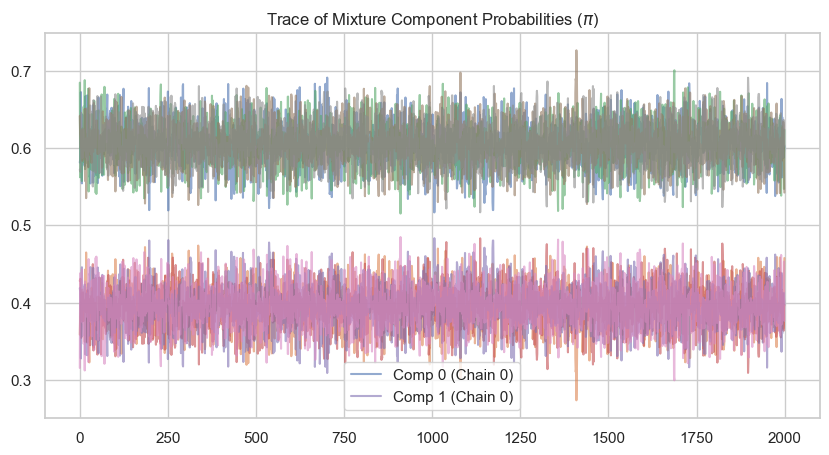


Plotting Sample Delta Diagnostics for Component 0...


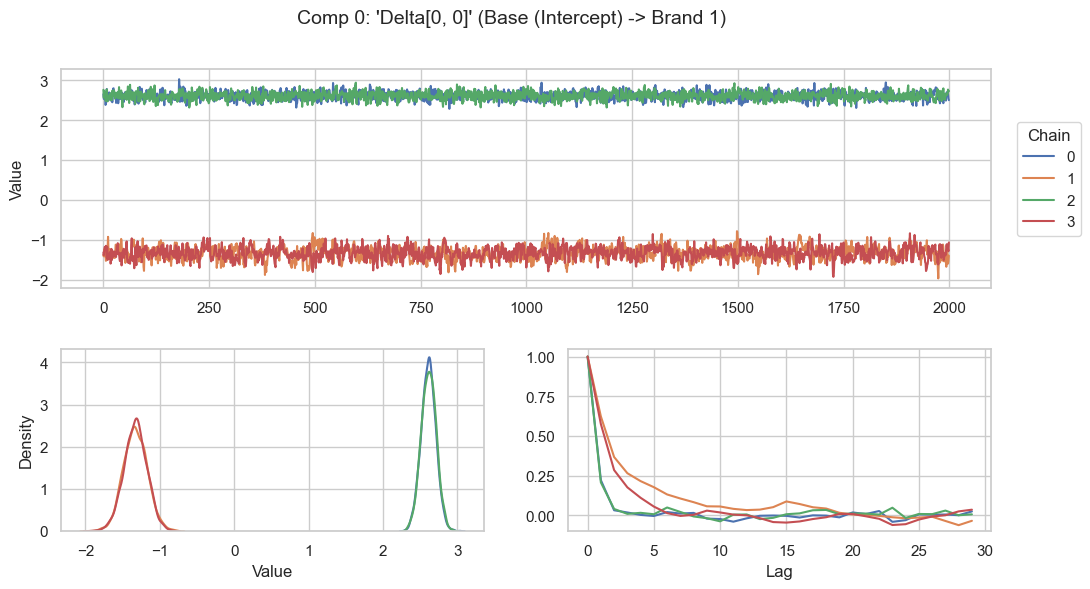

In [16]:
# ==========================================
# 5. MCMC DIAGNOSTICS & TRACE PLOTS
# ==========================================

print("\n=== Mixture Probabilities (Pi) ===")
# Convert logits to probabilities
w_logits_samples = posterior_samples["w_logits"]
pi_samples = jax.nn.softmax(w_logits_samples, axis=-1)

fig, ax = plt.subplots(figsize=(10, 5))
for k in range(K_COMPONENTS):
    for chain in range(pi_samples.shape[0]):
        ax.plot(pi_samples[chain, :, k], label=f"Comp {k} (Chain {chain})" if chain==0 else "", alpha=0.6)
ax.set_title("Trace of Mixture Component Probabilities ($\pi$)")
ax.legend()
plt.show()

def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm = np.sum(x_centered**2)
    if norm == 0: return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    acf = acf[acf.size // 2:] / norm
    return acf[:nlags]

def plot_mixture_goose_style(delta_array, k, demo_idx, param_idx, demo_name, param_name):
    n_chains = delta_array.shape[0]
    fig = plt.figure(figsize=(12, 6))
    fig.suptitle(f"Comp {k}: 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})", fontsize=14)
    
    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)
    
    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, k, demo_idx, param_idx], label=f"{chain}")
    ax_trace.set_ylabel("Value"); ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5))
    
    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, k, demo_idx, param_idx], ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    
    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains):
        ax_acf.plot(compute_acf(delta_array[chain, :, k, demo_idx, param_idx]), alpha=1)
    ax_acf.set_xlabel("Lag"); ax_acf.set_ylim(-0.1, 1.05)
    
    plt.show()

print("\nPlotting Sample Delta Diagnostics for Component 0...")
# Plotting just a few to avoid overwhelming the notebook output
raw_delta_samples = posterior_samples["Delta"]
plot_mixture_goose_style(raw_delta_samples, k=0, demo_idx=0, param_idx=0, demo_name=demo_names[0], param_name=param_names[0])


Recovering Covariance Matrices (Sigma)...
Sigma Samples Shape: (4, 2000, 2, 4, 4) (Chains, Draws, K, Params, Params)

Plotting Household Beta Recovery...


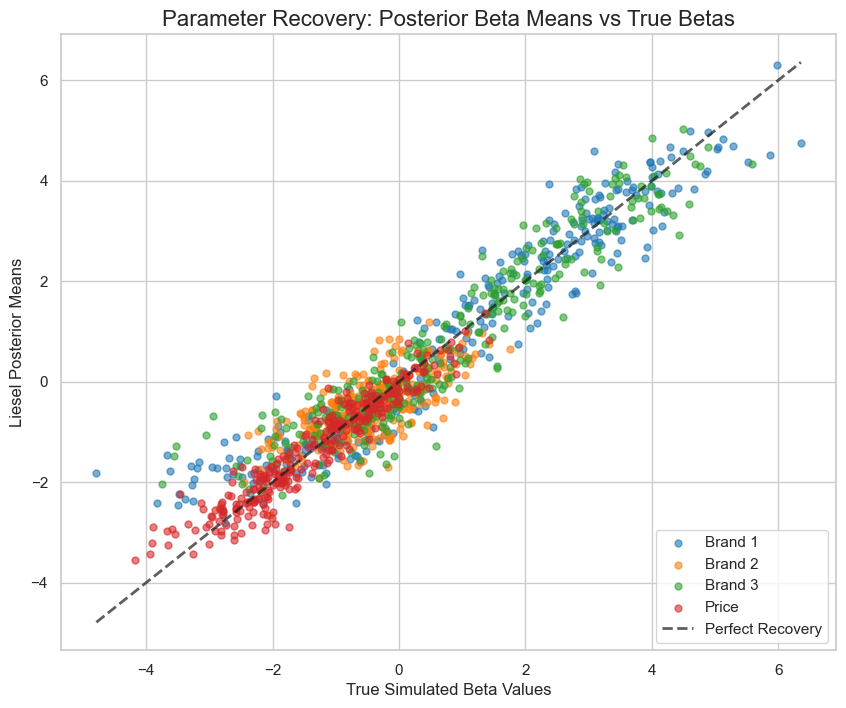

In [17]:
# ==========================================
# 6. COVARIANCE RECOVERY
# ==========================================
print("\nRecovering Covariance Matrices (Sigma)...")
bijector = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    return jnp.linalg.inv(L @ L.T)

# Vectorize across chains, draws, AND components
v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))

latent_samples = posterior_samples["sigma_inv_chol_latent"]
sigma_samples = v_latent_to_sigma(latent_samples)

print(f"Sigma Samples Shape: {sigma_samples.shape} (Chains, Draws, K, Params, Params)")


# ==================================
# 7. HOUSEHOLD HETEROGENEITY (BETAS)
# ==================================
print("\nPlotting Household Beta Recovery...")

# Flatten chains/draws for Betas
n_chains, n_draws, n_units, n_params = posterior_samples["beta_i"].shape
liesel_beta_full = posterior_samples["beta_i"].reshape(-1, n_units, n_params)
true_betas_full = choice_data["TRUE_BETA"]

l_beta_means = np.mean(liesel_beta_full, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, param in enumerate(param_names):
    ax.scatter(true_betas_full[:, i], l_beta_means[:, i], alpha=0.6, s=25, label=param, color=colors[i])

min_val = min(true_betas_full.min(), l_beta_means.min())
max_val = max(true_betas_full.max(), l_beta_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.7, label='Perfect Recovery')

ax.set_title("Parameter Recovery: Posterior Beta Means vs True Betas", fontsize=16)
ax.set_xlabel("True Simulated Beta Values")
ax.set_ylabel("Liesel Posterior Means")
ax.legend(loc='lower right')
plt.show()

In [20]:
# ==============================
# 4. DATA PROCESSING & RESHAPING
# ==============================
print("Standardizing array shapes for comparison...")

n_demos = choice_data["n_z"]

# Delta: (chains, draws, K, n_demos, n_params)
raw_delta_samples = posterior_samples["Delta"]
n_chains, n_draws, K, n_demos, n_params = raw_delta_samples.shape

# Flatten chains/draws -> (total_draws, K, n_demos, n_params)
delta_samples_flat = raw_delta_samples.reshape(-1, K, n_demos, n_params)

# Mixture weights: (chains, draws, K) -> probabilities
w_logits_samples  = posterior_samples["w_logits"]
pi_samples        = jax.nn.softmax(w_logits_samples, axis=-1)   # (chains, draws, K)
pi_samples_flat   = pi_samples.reshape(-1, K)                   # (total_draws, K)

# Covariance: recover sigma per segment
bijector = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    return jnp.linalg.inv(L @ L.T)

# Vectorize over chains, draws, AND components
v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))

latent_samples = posterior_samples["sigma_inv_chol_latent"]   # (chains, draws, K, n_latent)
sigma_samples  = v_latent_to_sigma(latent_samples)             # (chains, draws, K, P, P)
sigma_flat     = sigma_samples.reshape(-1, K, n_params, n_params)

print(f"Delta samples shape  : {delta_samples_flat.shape}  (draws, K, demos, params)")
print(f"Pi samples shape     : {pi_samples_flat.shape}     (draws, K)")
print(f"Sigma samples shape  : {sigma_flat.shape}          (draws, K, params, params)")

Standardizing array shapes for comparison...
Delta samples shape  : (8000, 2, 2, 4)  (draws, K, demos, params)
Pi samples shape     : (8000, 2)     (draws, K)
Sigma samples shape  : (8000, 2, 4, 4)          (draws, K, params, params)


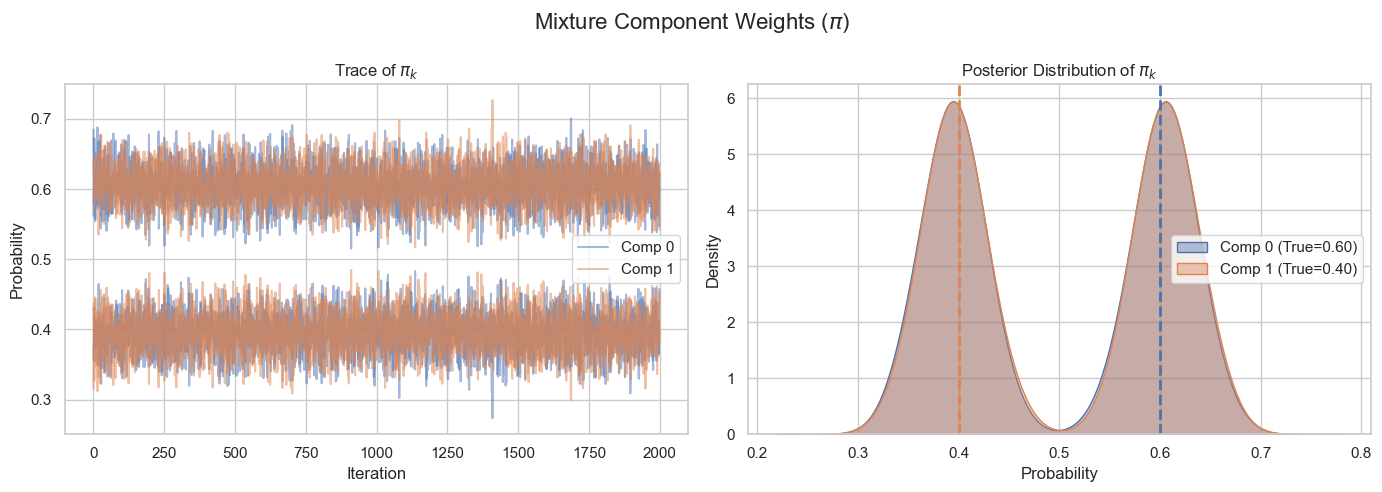

In [21]:
# ==========================================
# 5. MIXTURE WEIGHTS DIAGNOSTICS
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mixture Component Weights ($\\pi$)", fontsize=16)

colors_k = [f"C{k}" for k in range(K)]

# Trace
ax_trace = axes[0]
for k in range(K):
    for chain in range(n_chains):
        ax_trace.plot(
            pi_samples[chain, :, k],
            color=colors_k[k],
            alpha=0.5,
            label=f"Comp {k}" if chain == 0 else ""
        )
ax_trace.set_title("Trace of $\\pi_k$")
ax_trace.set_xlabel("Iteration")
ax_trace.set_ylabel("Probability")
ax_trace.legend()

# Density
ax_dens = axes[1]
for k in range(K):
    true_pi = choice_data["TRUE_PI"][k]
    sns.kdeplot(pi_samples_flat[:, k], ax=ax_dens, fill=True,
                color=colors_k[k], alpha=0.4, label=f"Comp {k} (True={true_pi:.2f})")
    ax_dens.axvline(true_pi, color=colors_k[k], linestyle="--", lw=2)

ax_dens.set_title("Posterior Distribution of $\\pi_k$")
ax_dens.set_xlabel("Probability")
ax_dens.legend()

plt.tight_layout()
plt.show()

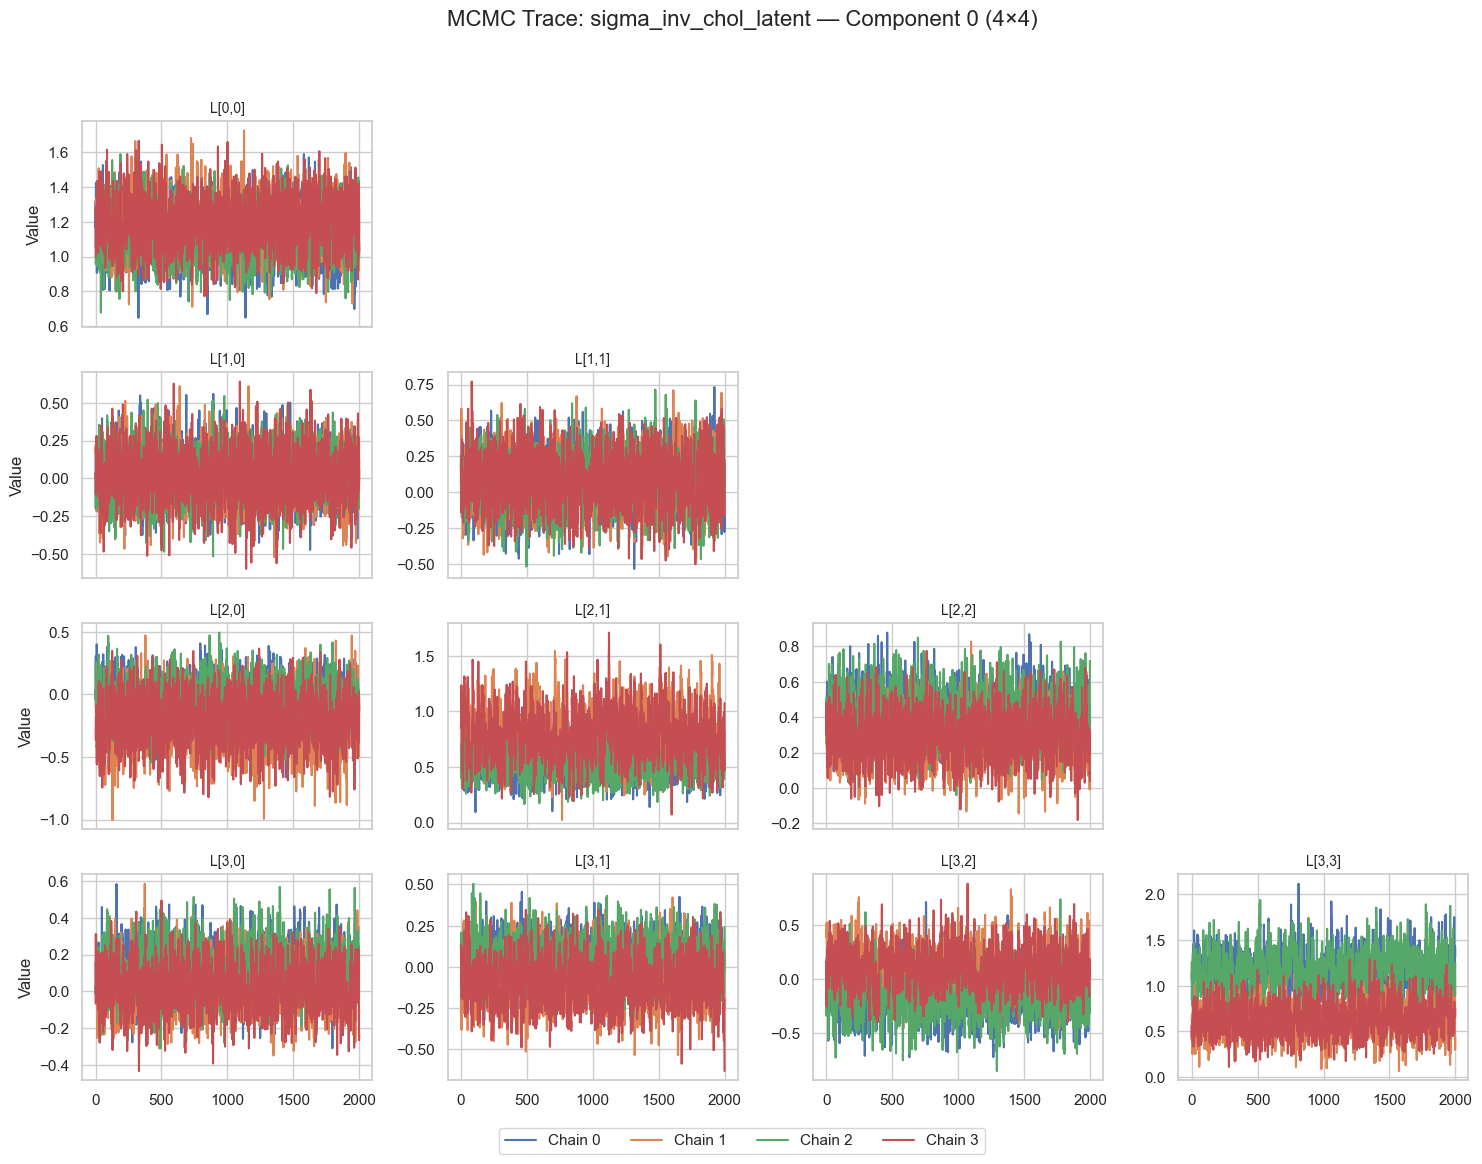

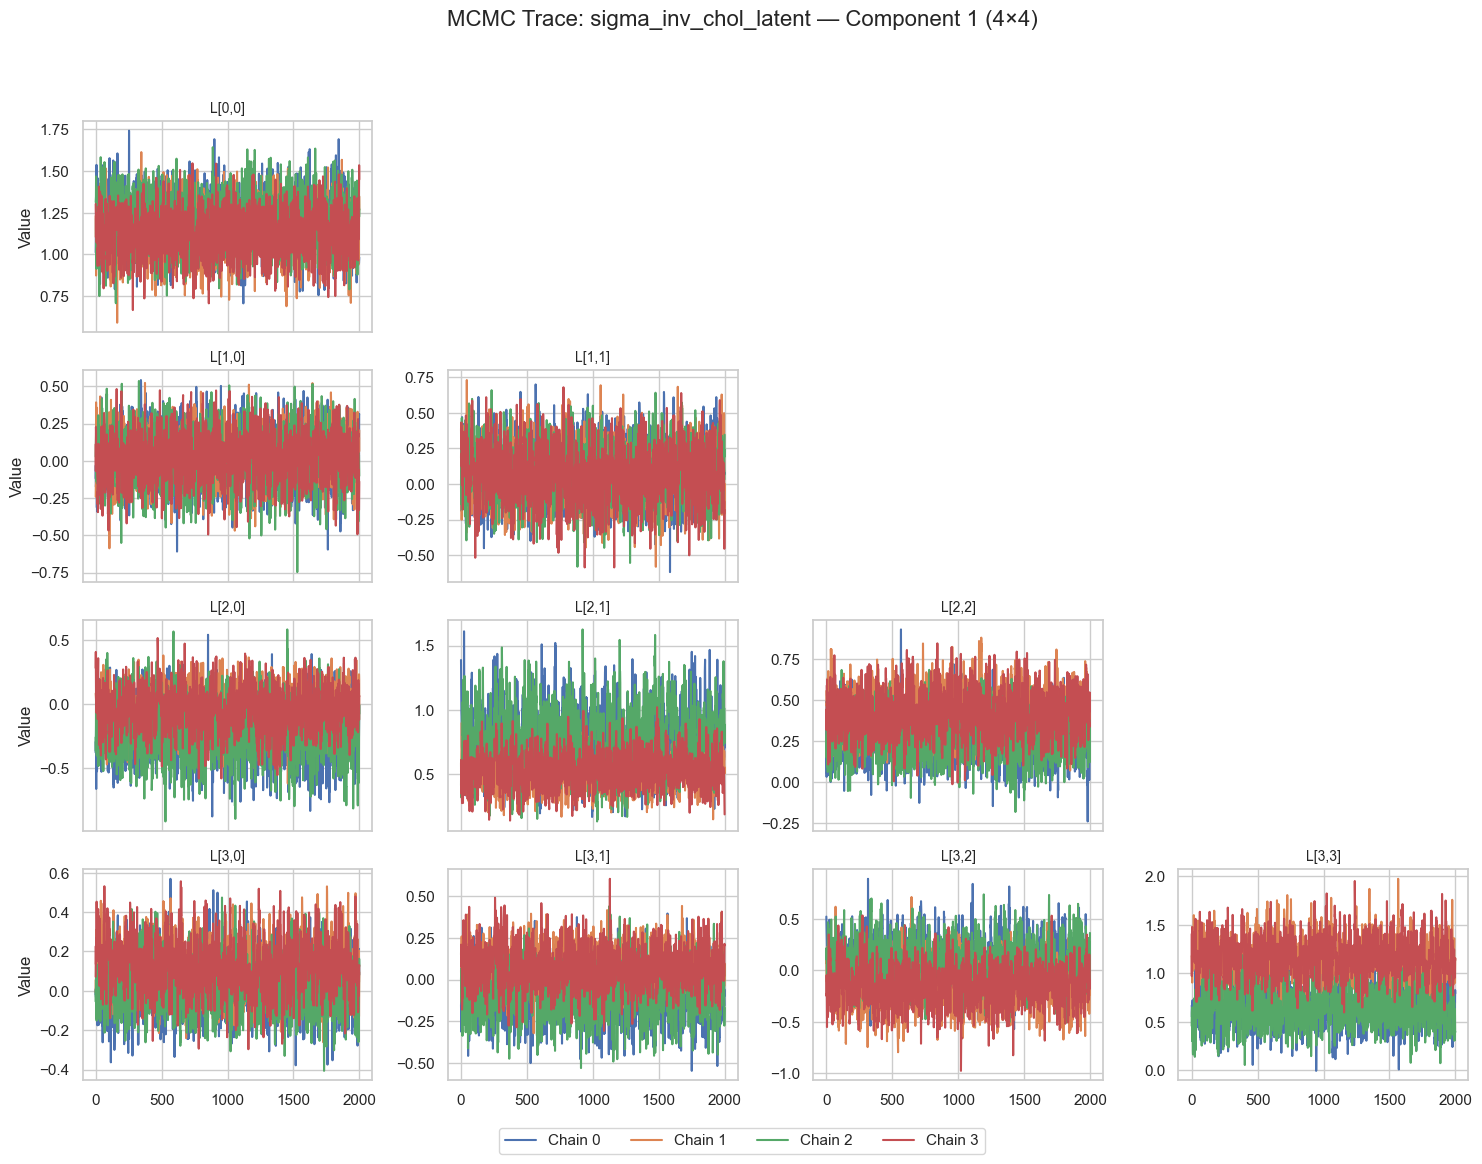

In [23]:
# ==========================================
# 6. CHOLESKY TRACES — PER COMPONENT
# ==========================================

def plot_cholesky_traces_mixture(samples_dict, n_params, K,
                                  param_name="sigma_inv_chol_latent",
                                  figsize=(15, 12)):
    """
    Plots MCMC trace plots for the latent Cholesky parameters, one figure per component.
    latent_samples shape: (chains, draws, K, n_latent)
    """
    latent_samples = samples_dict[param_name]   # (chains, draws, K, n_latent)
    n_chains, n_draws, K_actual, n_latent = latent_samples.shape

    for k in range(K_actual):
        fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True)
        if n_params == 1:
            axes = np.array([[axes]])

        latent_idx = 0
        for i in range(n_params):
            for j in range(n_params):
                ax = axes[i, j]
                if i >= j and latent_idx < n_latent:
                    for chain in range(n_chains):
                        ax.plot(latent_samples[chain, :, k, latent_idx],
                                label=f"Chain {chain}")
                    ax.set_title(f"L[{i},{j}]", fontsize=10)
                    latent_idx += 1
                else:
                    ax.axis('off')
                ax.grid(True)
                if j == 0:
                    ax.set_ylabel("Value")

        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=n_chains,
                   bbox_to_anchor=(0.5, 0.02))
        plt.suptitle(
            f"MCMC Trace: {param_name} — Component {k} ({n_params}×{n_params})",
            fontsize=16
        )
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()


plot_cholesky_traces_mixture(posterior_samples, n_params=n_params, K=K)


=== Goose-Style Delta Diagnostics — All Components ===

--- Component 0 ---


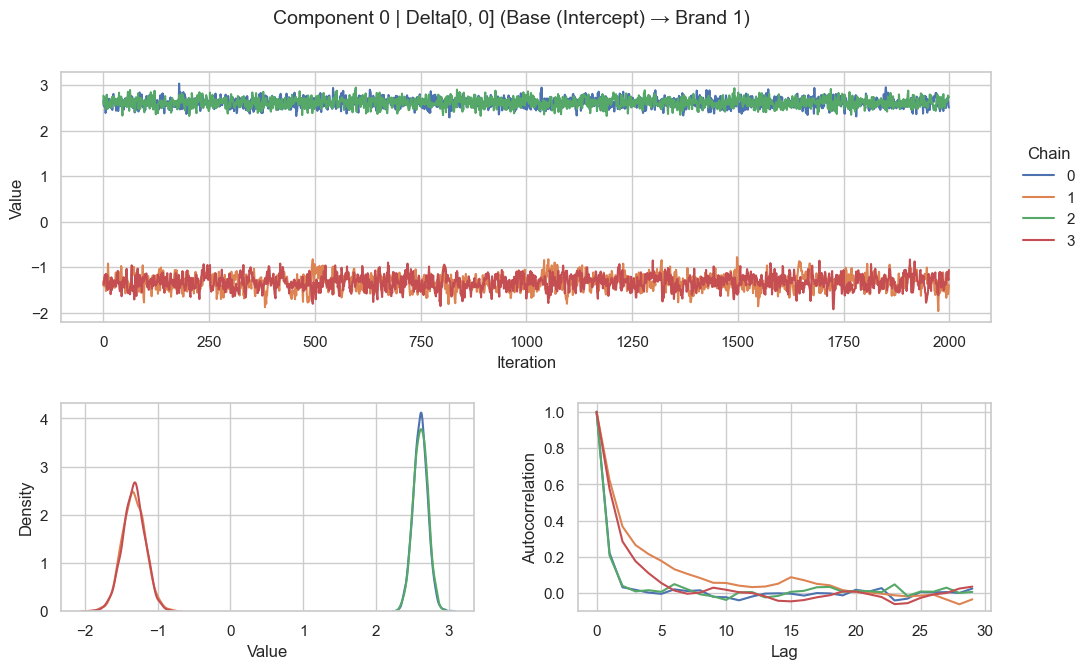

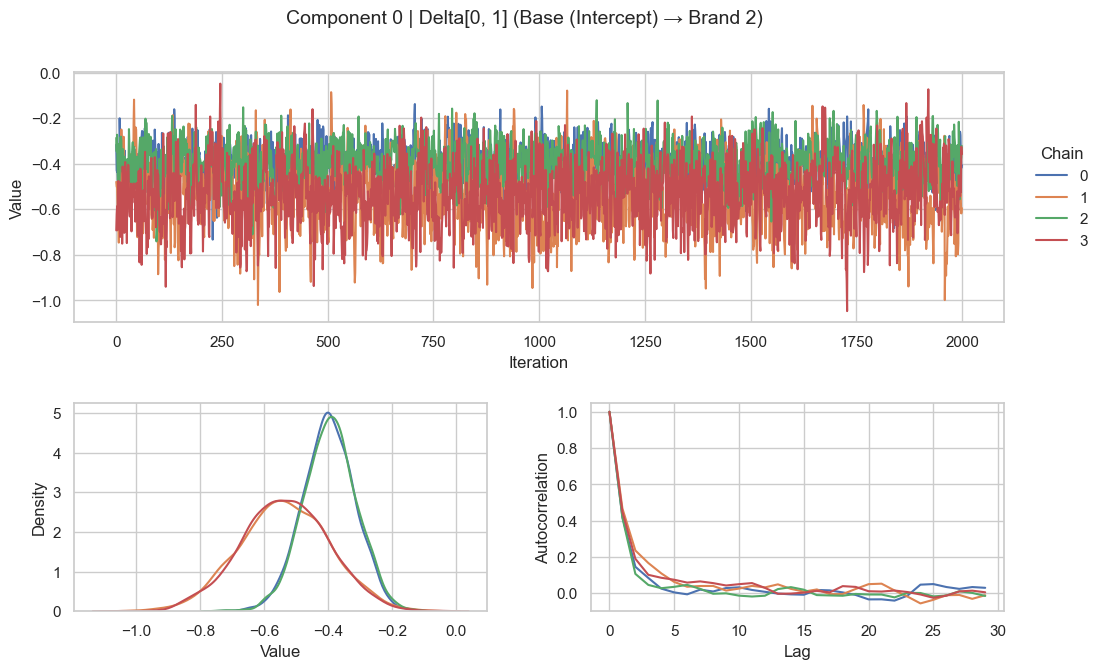

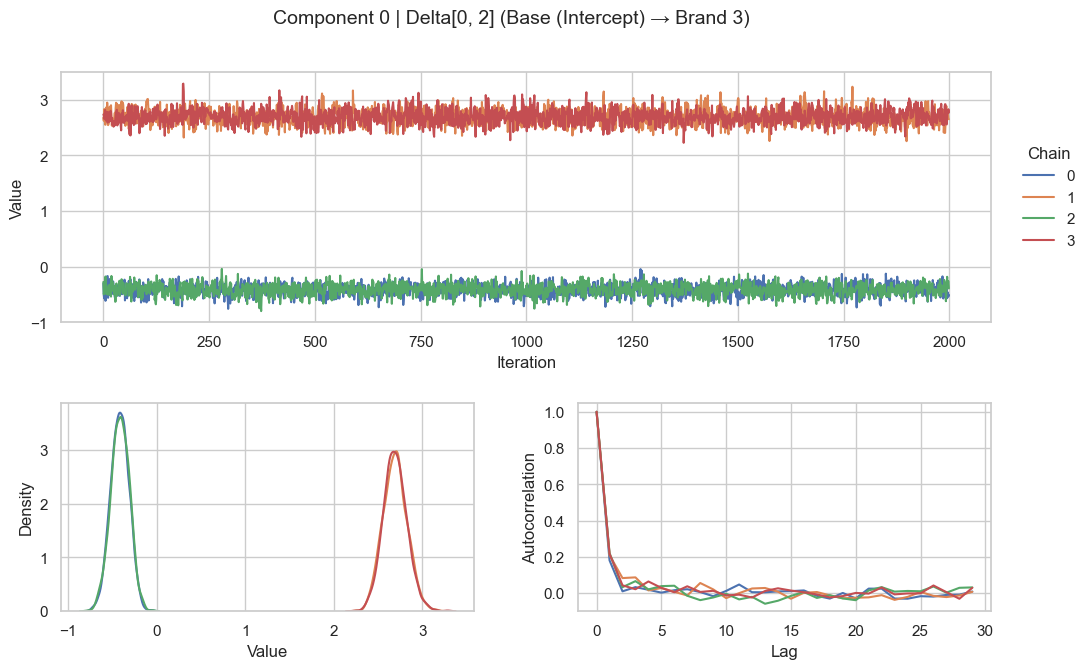

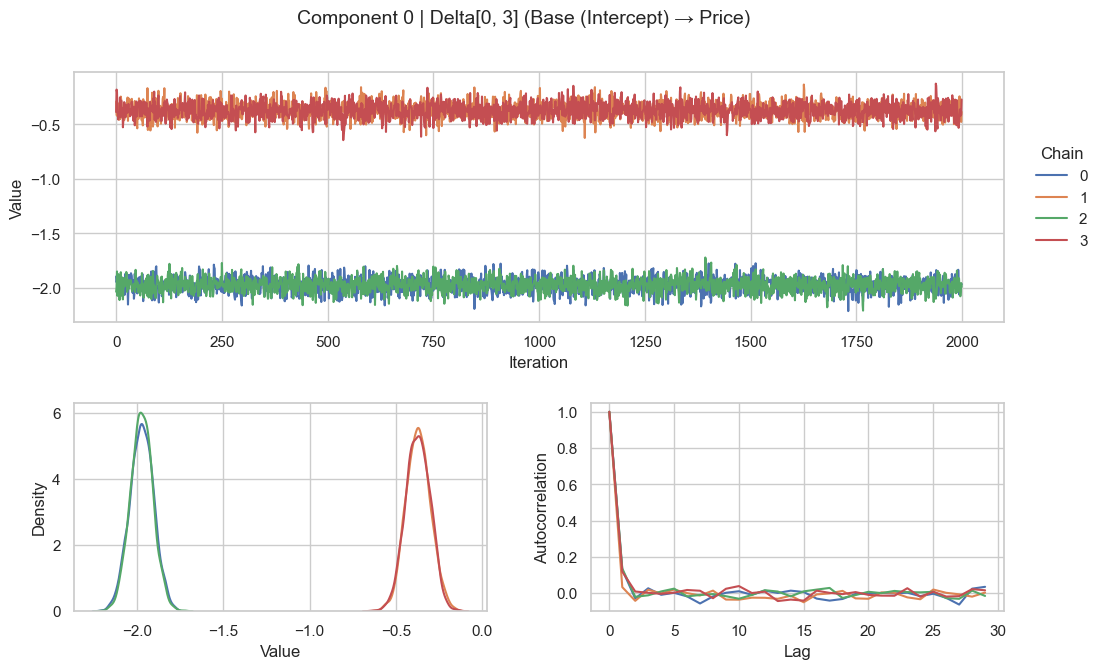

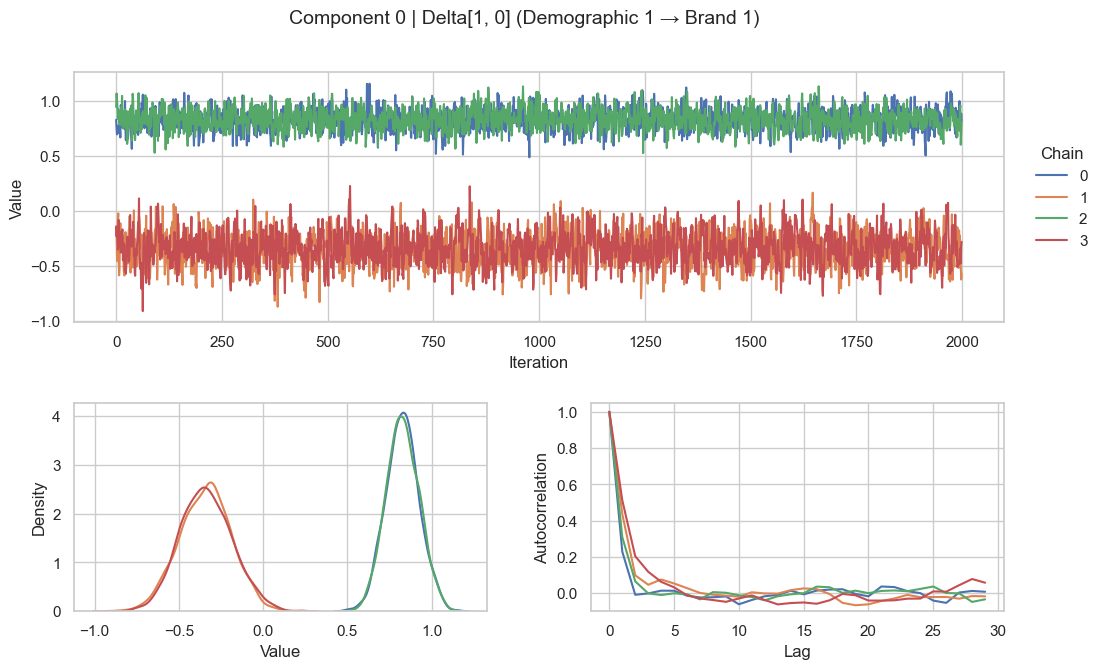

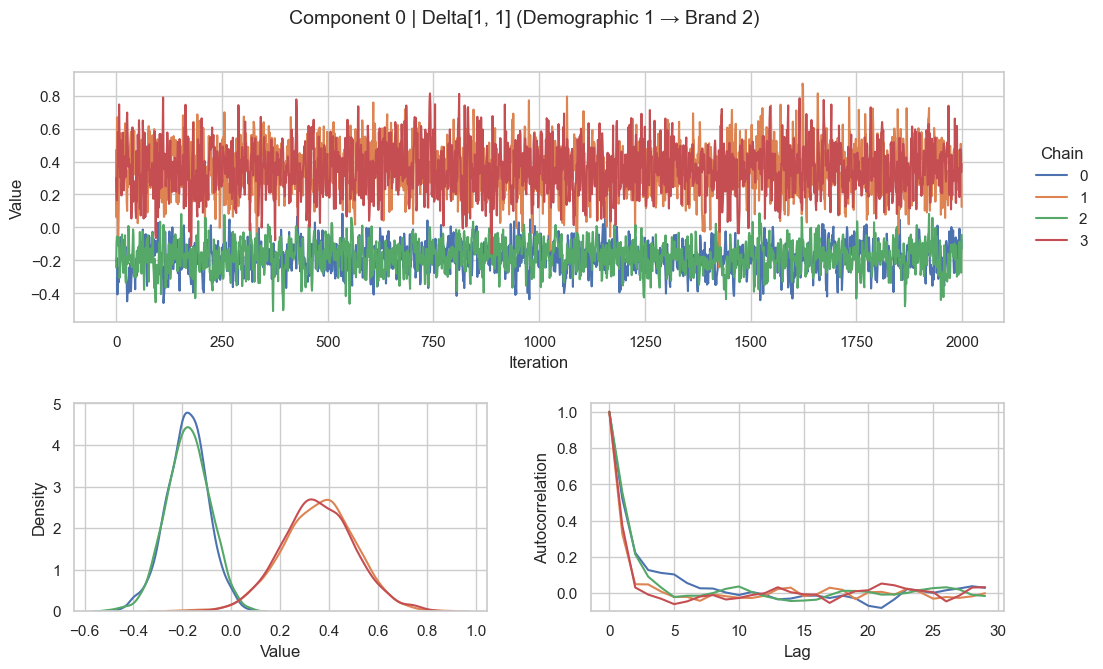

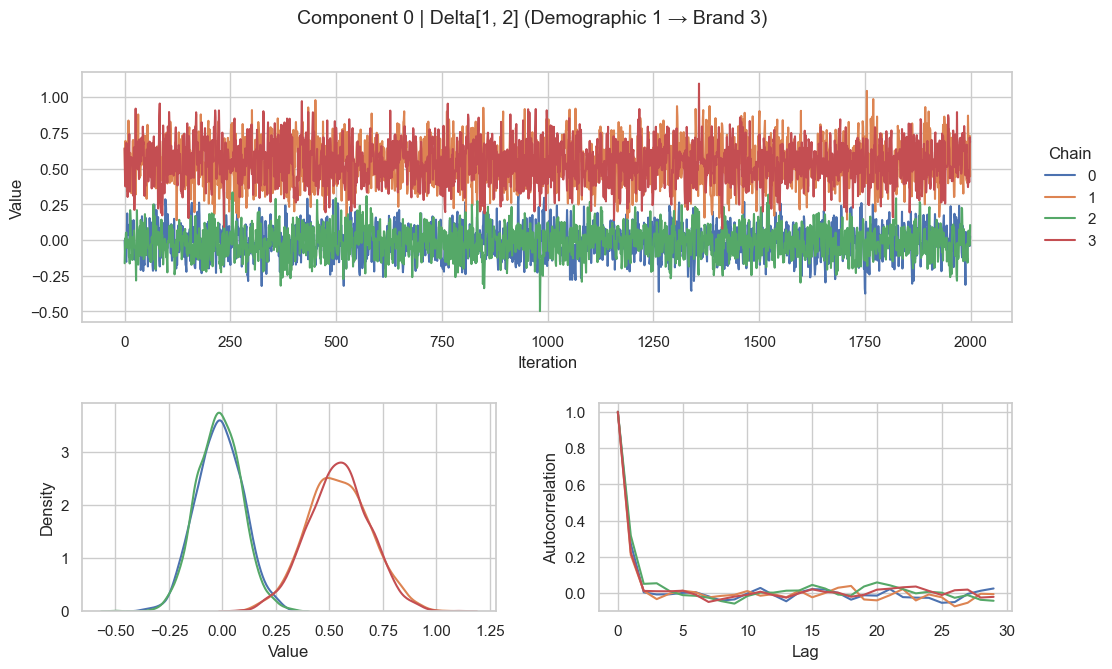

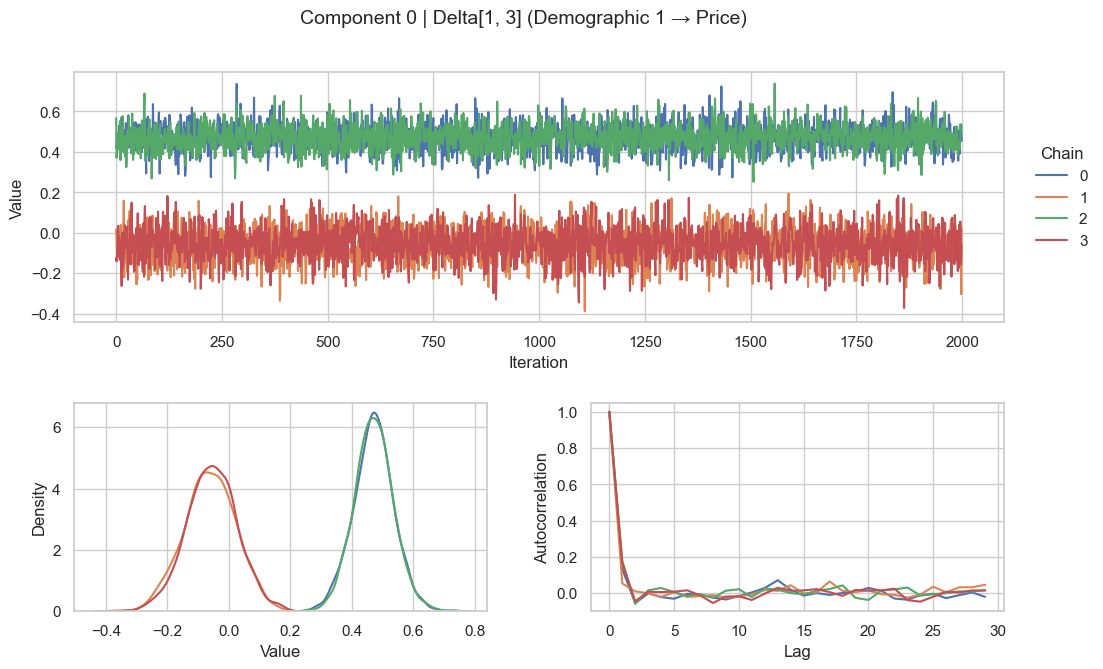


--- Component 1 ---


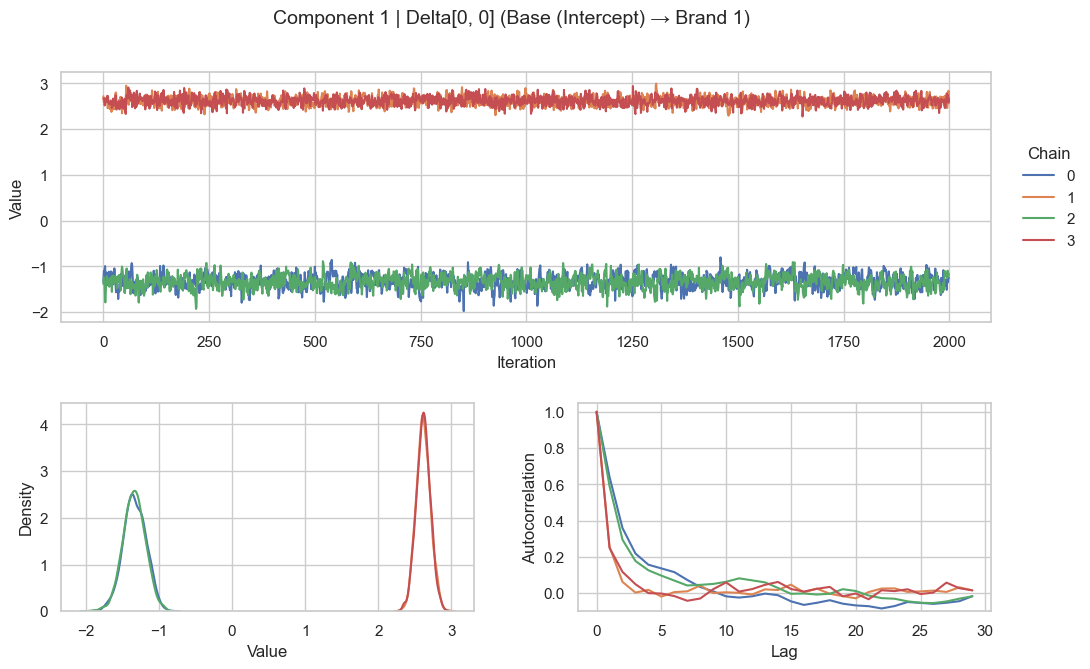

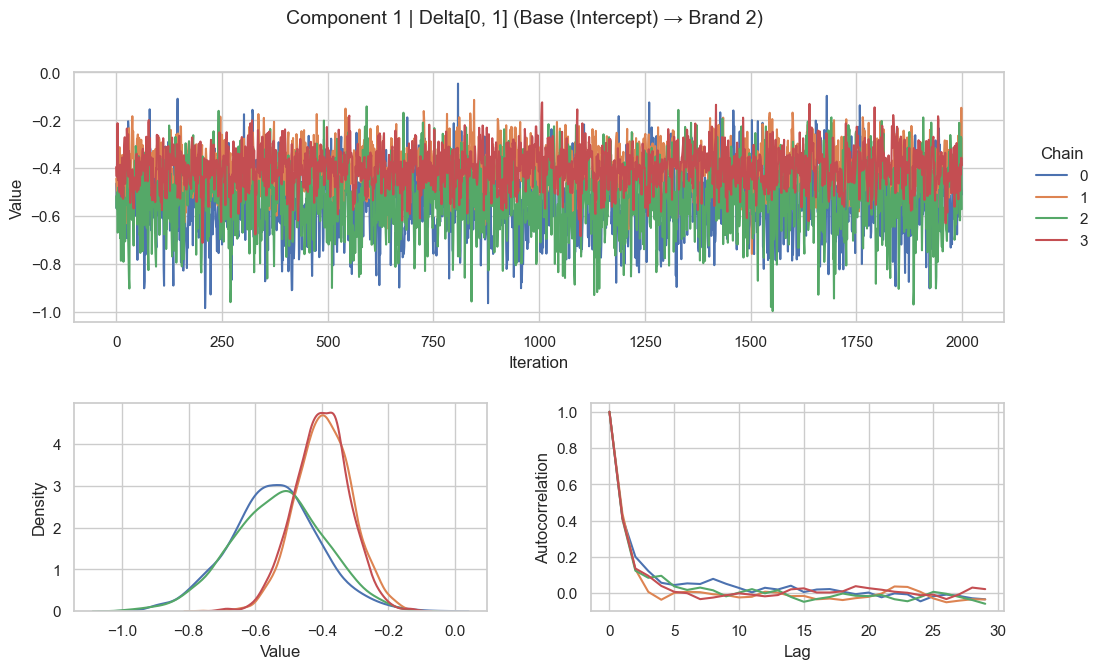

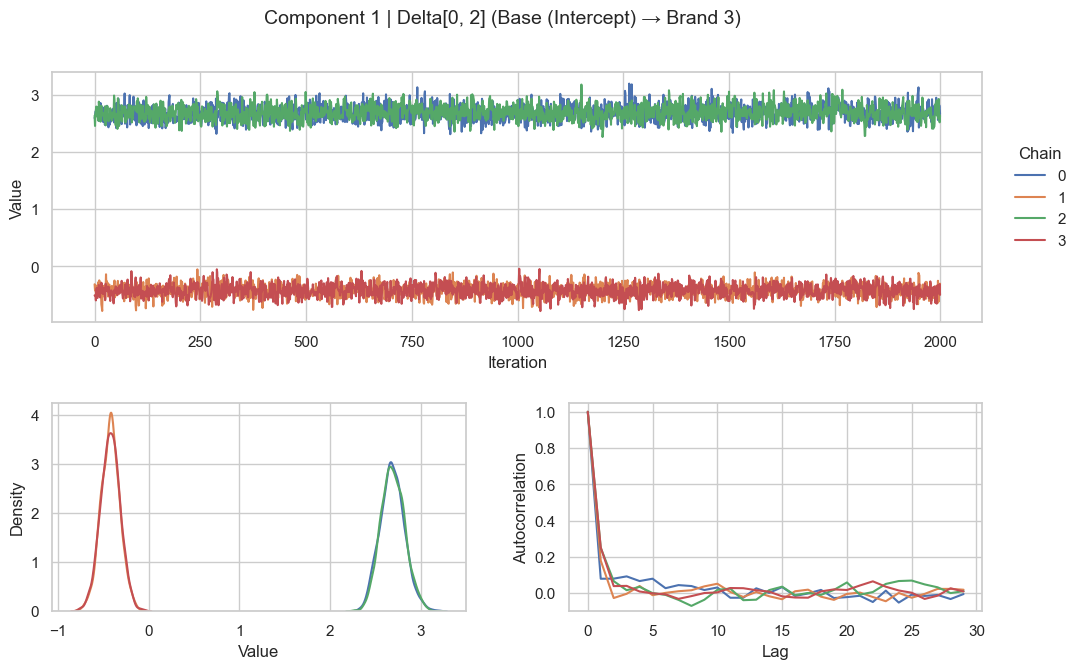

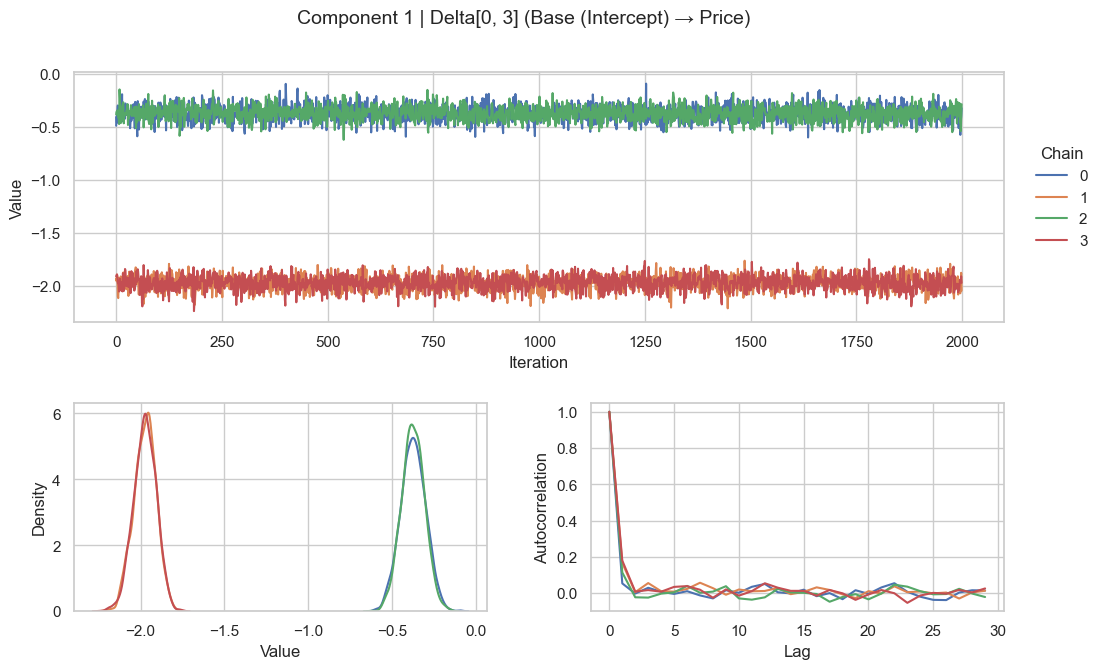

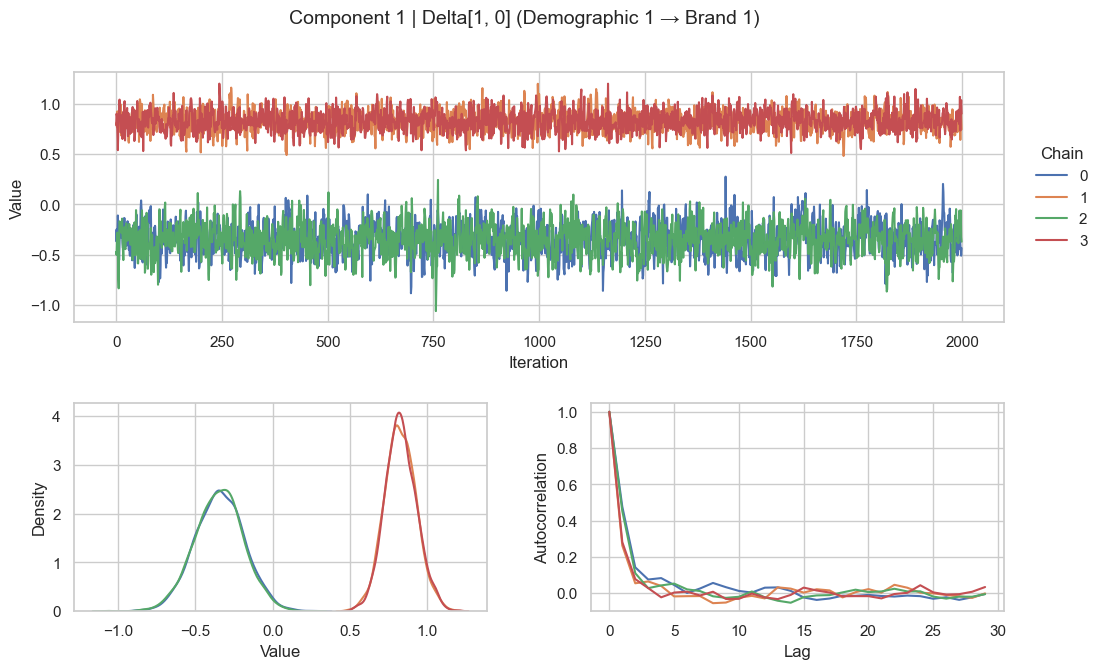

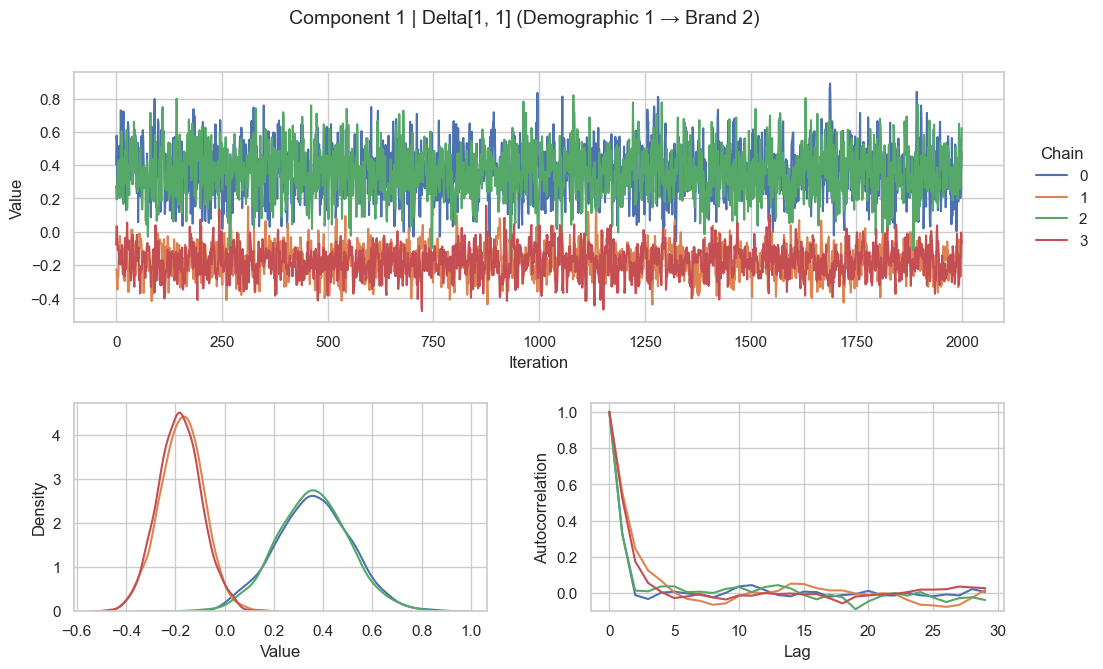

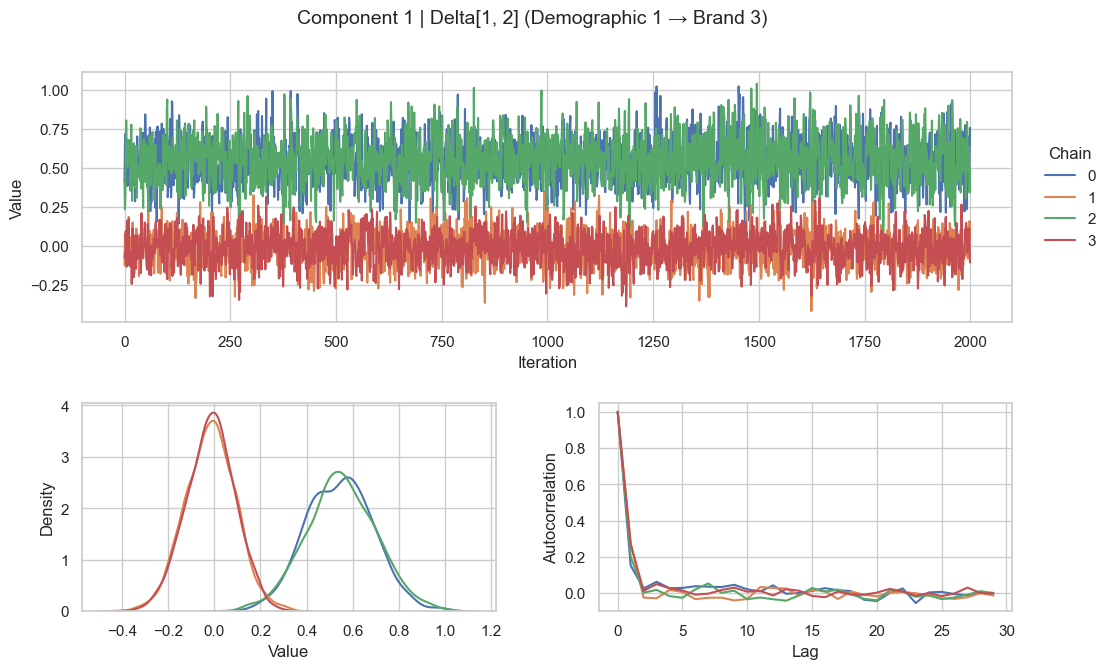

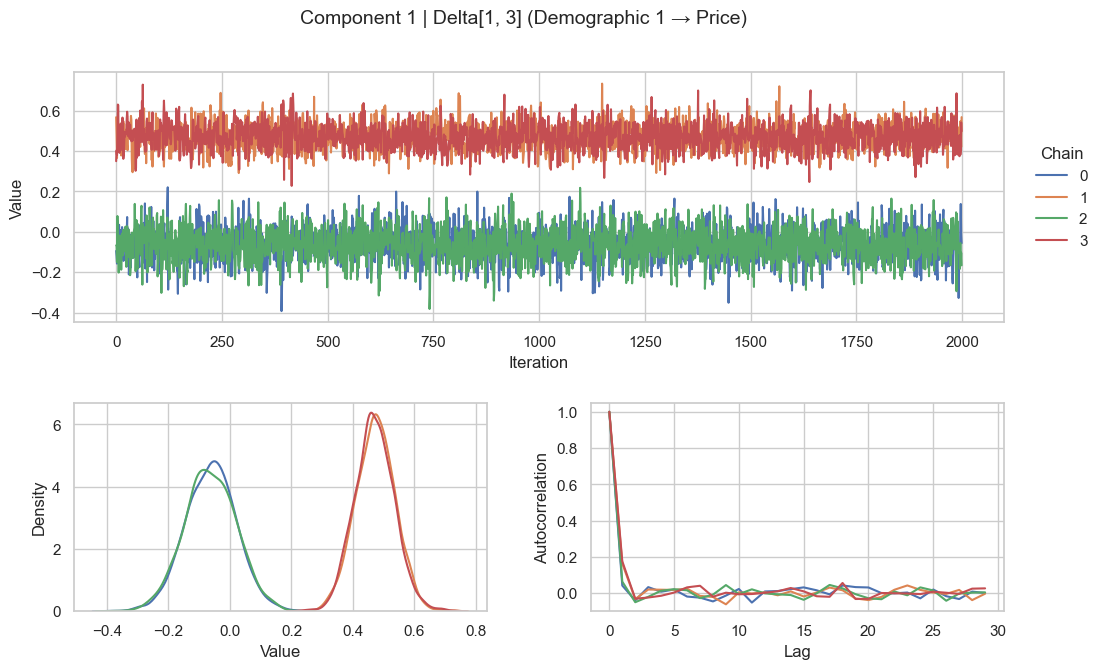

In [24]:
# ==========================================
# 7. GOOSE-STYLE DELTA DIAGNOSTICS — PER COMPONENT
# ==========================================

def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm = np.sum(x_centered**2)
    if norm == 0:
        return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    acf = acf[acf.size // 2:] / norm
    return acf[:nlags]


def plot_goose_style_mixture(delta_array, k, demo_idx, param_idx,
                              demo_name, param_name, n_lags=30):
    """
    Goose-style 3-panel diagnostic (Trace / Density / ACF) for
    Delta[k, demo_idx, param_idx].

    delta_array shape: (chains, draws, K, n_demos, n_params)
    """
    n_chains = delta_array.shape[0]

    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(
        f"Component {k} | Delta[{demo_idx}, {param_idx}]"
        f" ({demo_name} → {param_name})",
        fontsize=14, y=0.97
    )

    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1],
                                   hspace=0.35, wspace=0.25)

    # Trace
    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, k, demo_idx, param_idx],
                      label=f"{chain}")
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True)
    ax_trace.legend(title="Chain", loc='center left',
                    bbox_to_anchor=(1.02, 0.5), frameon=False)

    # Density
    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, k, demo_idx, param_idx],
                    ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)

    # ACF
    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains):
        acf_vals = compute_acf(
            delta_array[chain, :, k, demo_idx, param_idx], nlags=n_lags
        )
        ax_acf.plot(acf_vals)
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)

    plt.show()


print("\n=== Goose-Style Delta Diagnostics — All Components ===")
for k in range(K):
    print(f"\n--- Component {k} ---")
    for i in range(n_demos):
        for j in range(n_params):
            plot_goose_style_mixture(
                raw_delta_samples, k=k,
                demo_idx=i, param_idx=j,
                demo_name=demo_names[i],
                param_name=param_names[j]
            )

In [25]:
# ==========================================
# 8. DELTA SUMMARY TABLES — PER COMPONENT
# ==========================================

def generate_delta_table_mixture(delta_draws, k, p_names, d_names):
    """
    Returns a DataFrame of 'mean (std)' for Delta of component k.
    delta_draws shape: (total_draws, K, n_demos, n_params)
    """
    samples_k = delta_draws[:, k, :, :]            # (draws, demos, params)
    mean = np.mean(samples_k, axis=0)
    std  = np.std(samples_k,  axis=0)

    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]: .2f} ({std[i, j]:.2f})"
    return df


def generate_delta_diff_table_mixture(true_delta_k, delta_draws, k, p_names, d_names):
    """
    |True - Posterior mean| for component k.
    true_delta_k shape: (n_demos, n_params)
    """
    mean_k  = np.mean(delta_draws[:, k, :, :], axis=0)
    diff    = np.abs(true_delta_k - mean_k)

    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{diff[i, j]:.3f}"
    return df


print("\n=== Global Parameter (Delta) Recovery — Per Component ===")
for k in range(K):
    true_delta_k = choice_data["TRUE_DELTA"][k]   # (n_demos, n_params)
    print(f"\n--- Component {k} ---")

    print("True Delta:")
    display(pd.DataFrame(true_delta_k, index=demo_names, columns=param_names))

    print("Posterior Delta  [mean (std)]:")
    display(generate_delta_table_mixture(delta_samples_flat, k, param_names, demo_names))

    print("|True − Posterior Mean|:")
    display(generate_delta_diff_table_mixture(
        true_delta_k, delta_samples_flat, k, param_names, demo_names
    ))


=== Global Parameter (Delta) Recovery — Per Component ===

--- Component 0 ---
True Delta:


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),2.5,-0.5,-0.5,-2.0
Demographic 1,0.8,-0.3,0.0,0.5


Posterior Delta  [mean (std)]:


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),0.64 (1.98),-0.47 (0.13),1.14 (1.56),-1.17 (0.80)
Demographic 1,0.24 (0.60),0.09 (0.29),0.26 (0.31),0.21 (0.28)


|True − Posterior Mean|:


...

,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),-1.5,-0.5,2.5,-0.5
Demographic 1,-0.5,0.2,0.5,-0.1


Posterior Delta  [mean (std)]:


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),0.64 (1.98),-0.47 (0.13),1.13 (1.56),-1.17 (0.80)
Demographic 1,0.24 (0.60),0.09 (0.30),0.27 (0.31),0.20 (0.28)


|True − Posterior Mean|:


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),2.141,0.033,1.366,0.674
Demographic 1,0.743,0.109,0.234,0.305



Plotting Delta Distributions per Component...


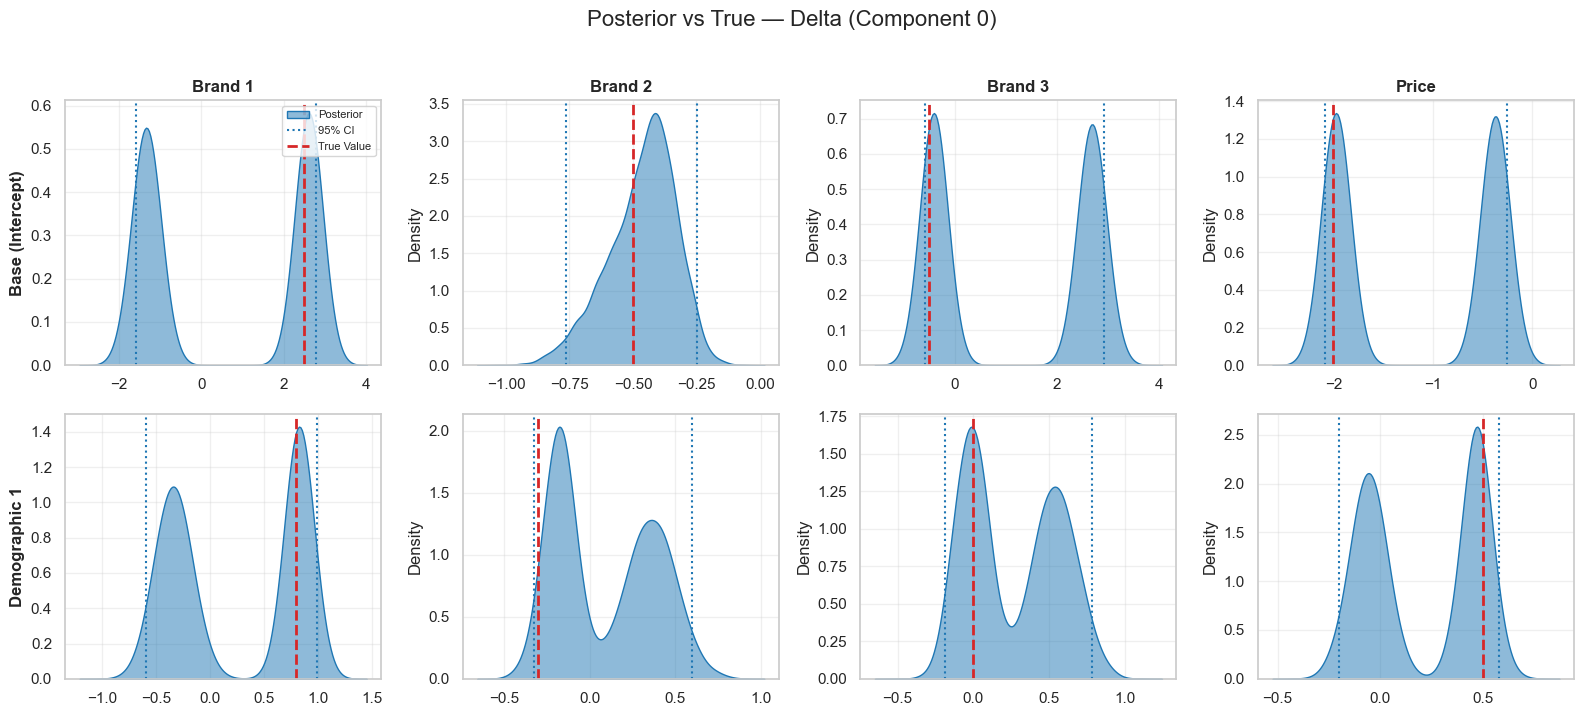

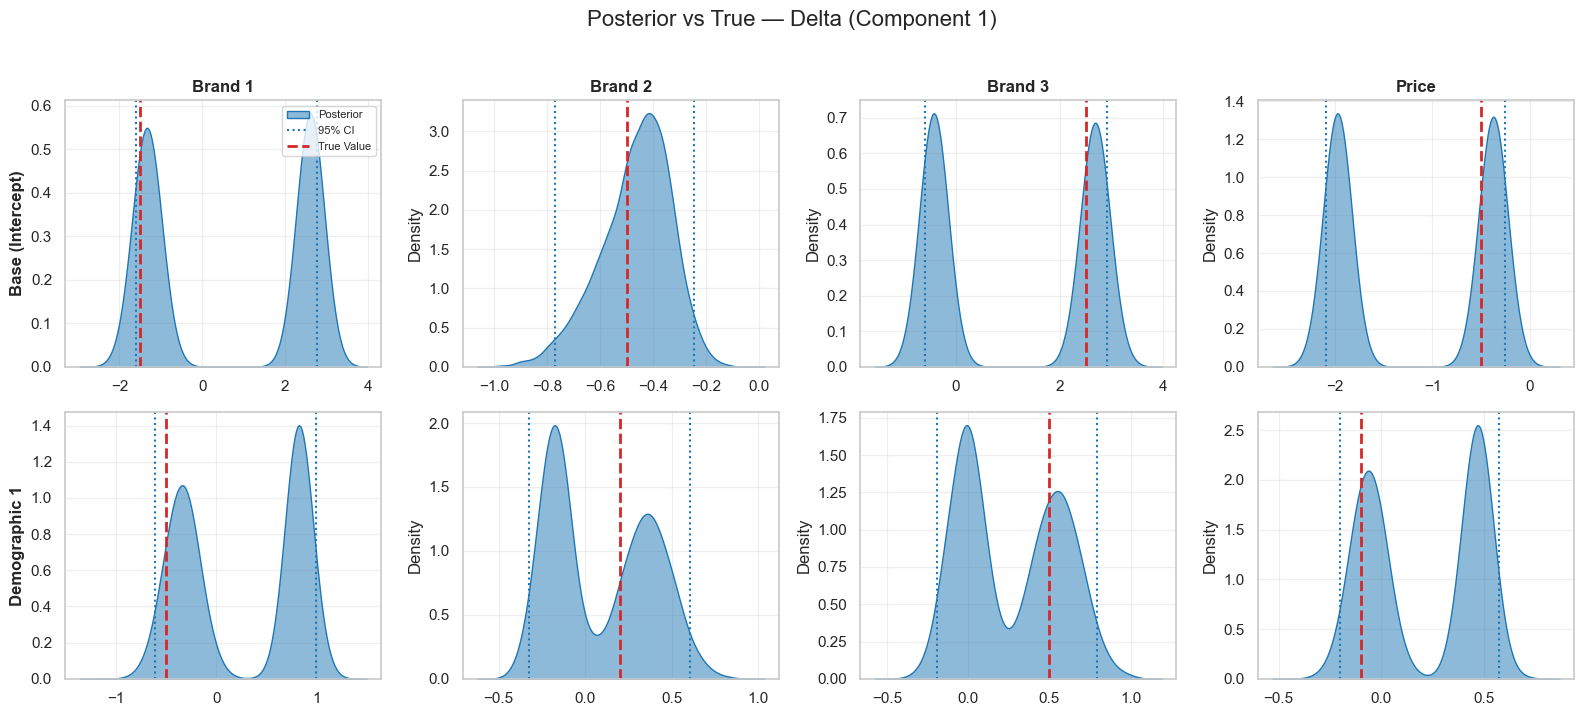

In [26]:
# ==========================================
# 9. DELTA POSTERIOR DISTRIBUTIONS — PER COMPONENT
# ==========================================

def plot_delta_distributions_mixture(delta_draws, true_delta_all, p_names, d_names, K):
    """
    One figure per component, one subplot per (demo × param) cell.
    delta_draws shape: (total_draws, K, n_demos, n_params)
    true_delta_all shape: (K, n_demos, n_params)
    """
    for k in range(K):
        fig, axes = plt.subplots(
            len(d_names), len(p_names),
            figsize=(4 * len(p_names), 3.5 * len(d_names))
        )
        if len(d_names) == 1:
            axes = axes[np.newaxis, :]

        for d in range(len(d_names)):
            for p in range(len(p_names)):
                ax      = axes[d, p]
                samples = delta_draws[:, k, d, p]
                t_val   = true_delta_all[k, d, p]
                ci_low, ci_high = np.percentile(samples, [2.5, 97.5])

                sns.kdeplot(samples, ax=ax, fill=True,
                            color="#1f77b4", alpha=0.5, label="Posterior")
                ax.axvline(ci_low,  color="#1f77b4", linestyle=":", lw=1.5,
                           label="95% CI")
                ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)
                ax.axvline(t_val,   color="#D62728", linestyle="--", lw=2,
                           label="True Value")

                if d == 0:
                    ax.set_title(p_names[p], fontweight='bold')
                if p == 0:
                    ax.set_ylabel(d_names[d], fontweight='bold')
                ax.grid(True, alpha=0.3)

                if d == 0 and p == 0:
                    handles, labels = ax.get_legend_handles_labels()
                    unique = [(h, l) for idx, (h, l) in
                              enumerate(zip(handles, labels))
                              if l not in labels[:idx]]
                    ax.legend(*zip(*unique), loc='upper right', fontsize=8)

        plt.suptitle(
            f"Posterior vs True — Delta (Component {k})",
            fontsize=16, y=1.02
        )
        plt.tight_layout()
        plt.show()


print("\nPlotting Delta Distributions per Component...")
plot_delta_distributions_mixture(
    delta_samples_flat,
    choice_data["TRUE_DELTA"],
    param_names, demo_names, K
)


Plotting Covariance Recovery per Component...


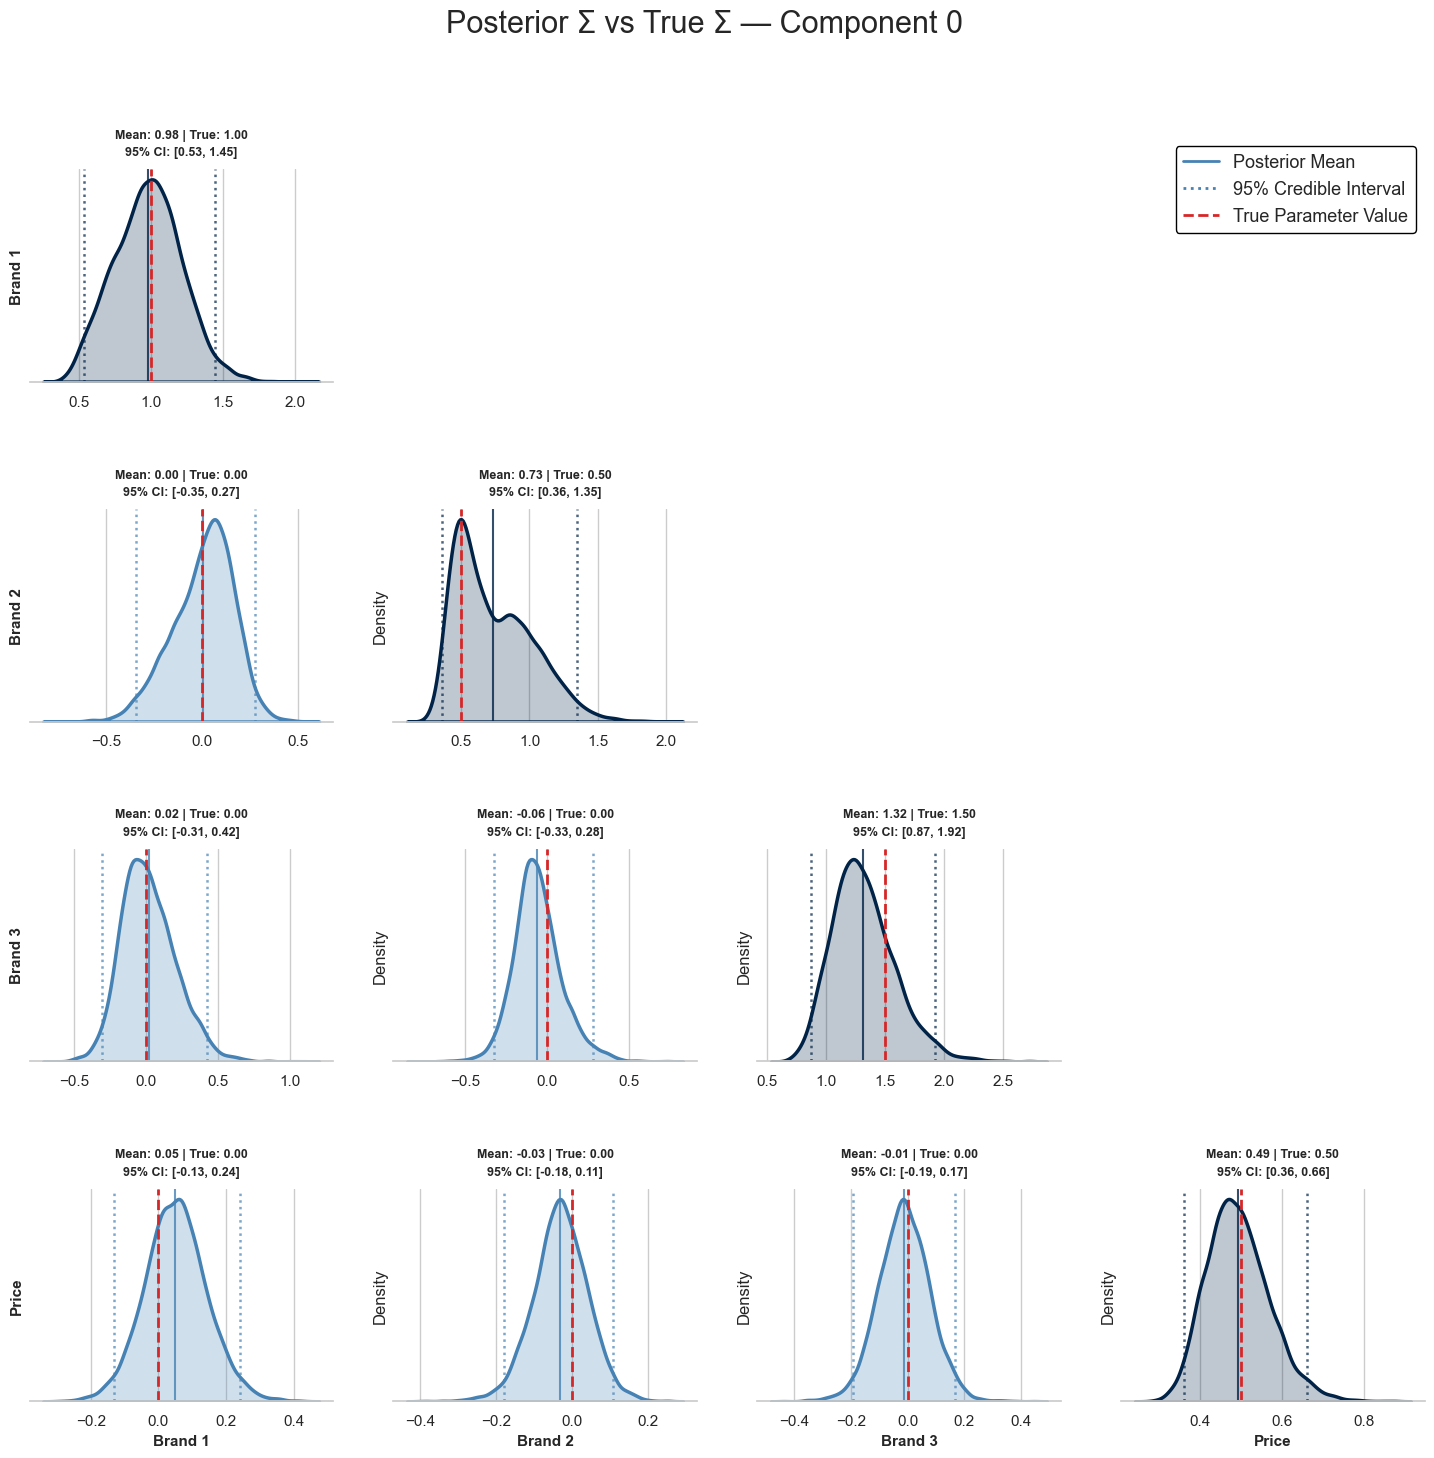

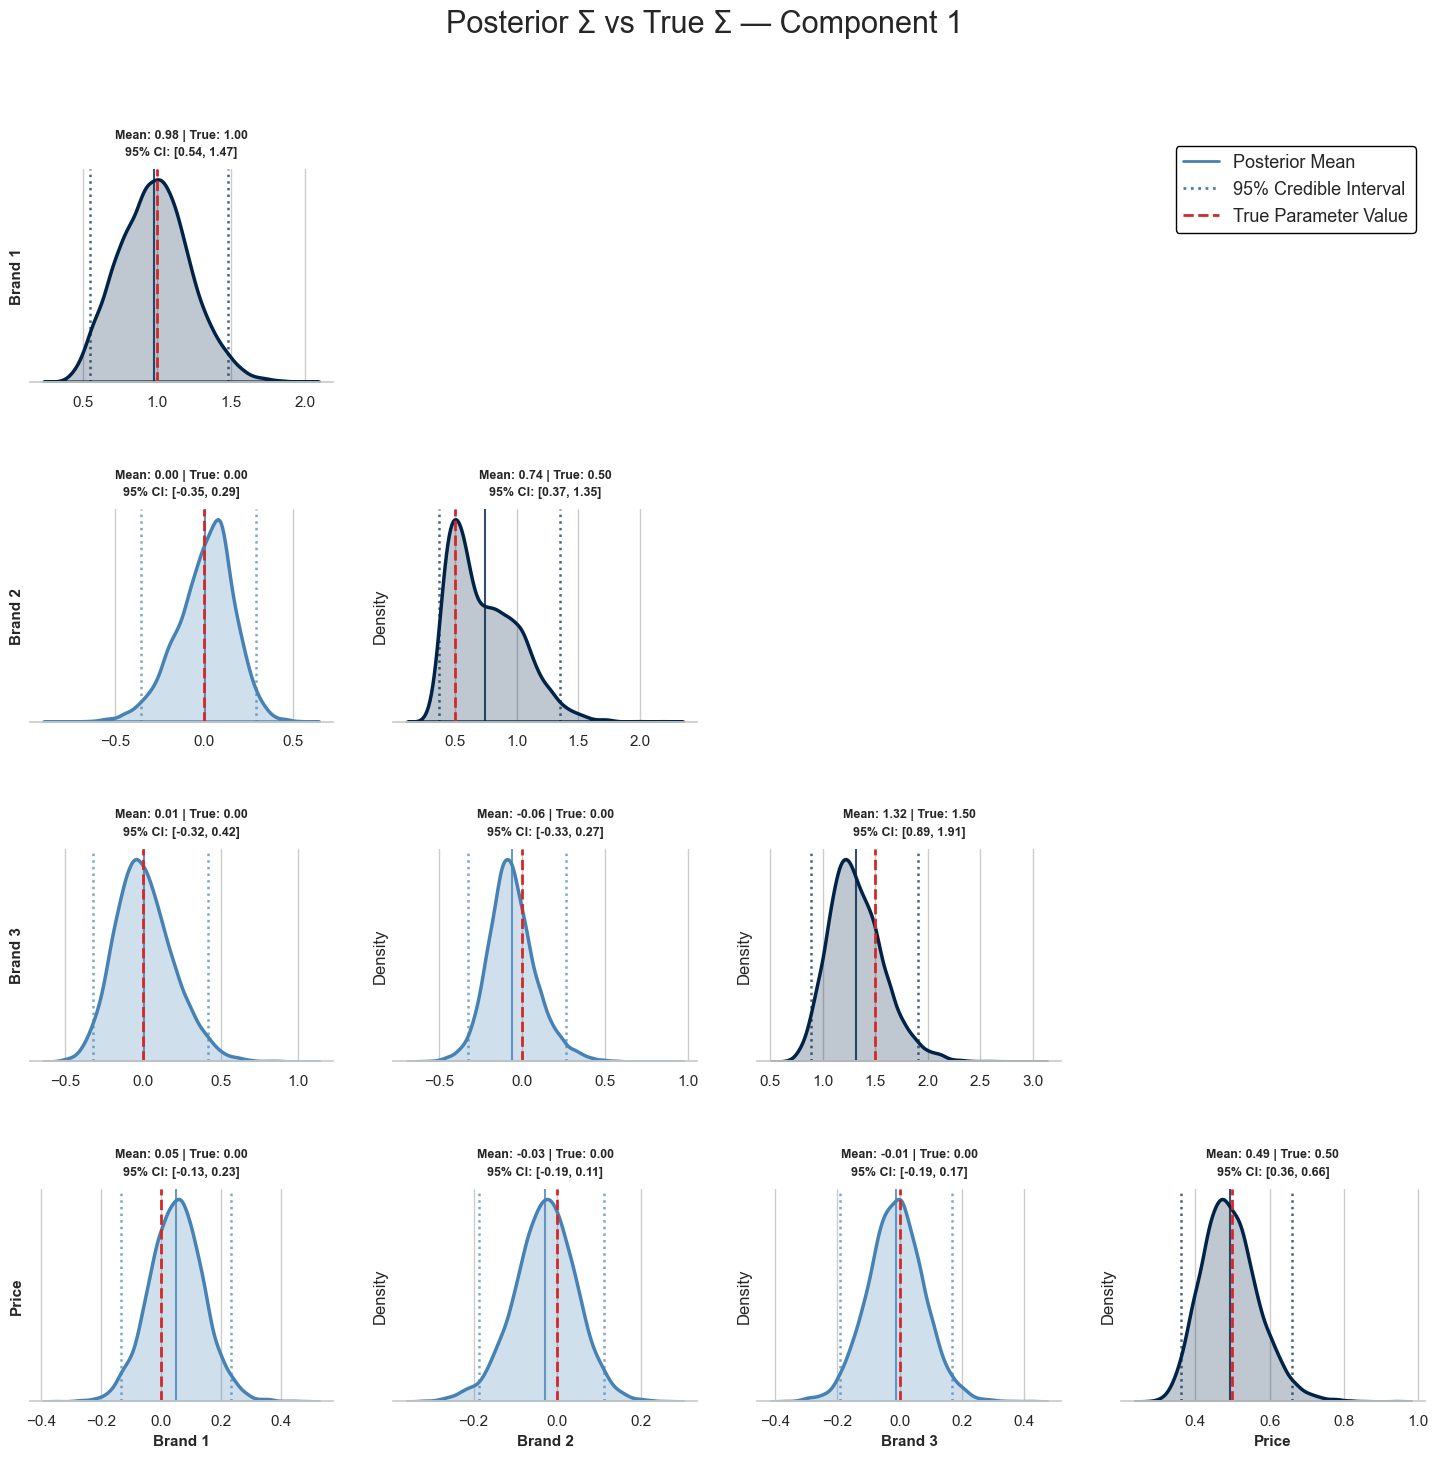

In [27]:
# ==========================================
# 10. COVARIANCE RECOVERY — PER COMPONENT
# ==========================================

from matplotlib.lines import Line2D

def plot_covariance_mixture(sigma_draws, true_sigma_all, K, p_names):
    """
    One lower-triangular KDE grid per component, mirroring plot_final_covariance_complete.
    sigma_draws shape: (total_draws, K, n_params, n_params)
    true_sigma_all shape: (K, n_params, n_params)
    """
    n_dim = len(p_names)
    diag_color     = "#002347"
    off_diag_color = "#4682B4"
    true_val_color = "#D62728"

    for k in range(K):
        samples_k = sigma_draws[:, k, :, :]       # (draws, P, P)
        true_k    = true_sigma_all[k]              # (P, P)

        fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))

        for i in range(n_dim):
            for j in range(n_dim):
                ax = axes[i, j]
                if j > i:
                    ax.axis('off')
                    continue

                data_vec     = samples_k[:, i, j]
                is_diag      = (i == j)
                current_color = diag_color if is_diag else off_diag_color

                post_mean            = np.mean(data_vec)
                ci_low, ci_high      = np.percentile(data_vec, [2.5, 97.5])
                true_val             = true_k[i, j]

                sns.kdeplot(data_vec, ax=ax, fill=True,
                            color=current_color, alpha=0.25, lw=2.5)
                ax.axvline(post_mean, color=current_color, lw=1.5, alpha=0.8)
                ax.axvline(ci_low,   color=current_color, linestyle=":", lw=1.8, alpha=0.7)
                ax.axvline(ci_high,  color=current_color, linestyle=":", lw=1.8, alpha=0.7)
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)

                title_str = (
                    f"Mean: {post_mean:.2f} | True: {true_val:.2f}\n"
                    f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
                )
                ax.set_title(title_str, fontsize=9, pad=10,
                             linespacing=1.6, fontweight='bold')
                ax.set_yticks([])
                sns.despine(ax=ax, left=True)

                if i == n_dim - 1:
                    ax.set_xlabel(p_names[j], fontsize=11, fontweight='bold')
                if j == 0:
                    ax.set_ylabel(p_names[i], fontsize=11, fontweight='bold')

        legend_elements = [
            Line2D([0], [0], color=off_diag_color, lw=2, label='Posterior Mean'),
            Line2D([0], [0], color=off_diag_color, linestyle=':', lw=2,
                   label='95% Credible Interval'),
            Line2D([0], [0], color=true_val_color, linestyle='--', lw=2,
                   label='True Parameter Value'),
        ]
        fig.legend(handles=legend_elements, loc='upper right',
                   bbox_to_anchor=(0.9, 0.9), fontsize=13,
                   frameon=True, edgecolor='black', framealpha=1)

        plt.suptitle(
            f"Posterior Σ vs True Σ — Component {k}",
            fontsize=22, y=0.98, fontweight='light'
        )
        plt.subplots_adjust(hspace=0.6, wspace=0.2)
        plt.show()


print("\nPlotting Covariance Recovery per Component...")
plot_covariance_mixture(sigma_flat, choice_data["TRUE_SIGMA"], K, param_names)

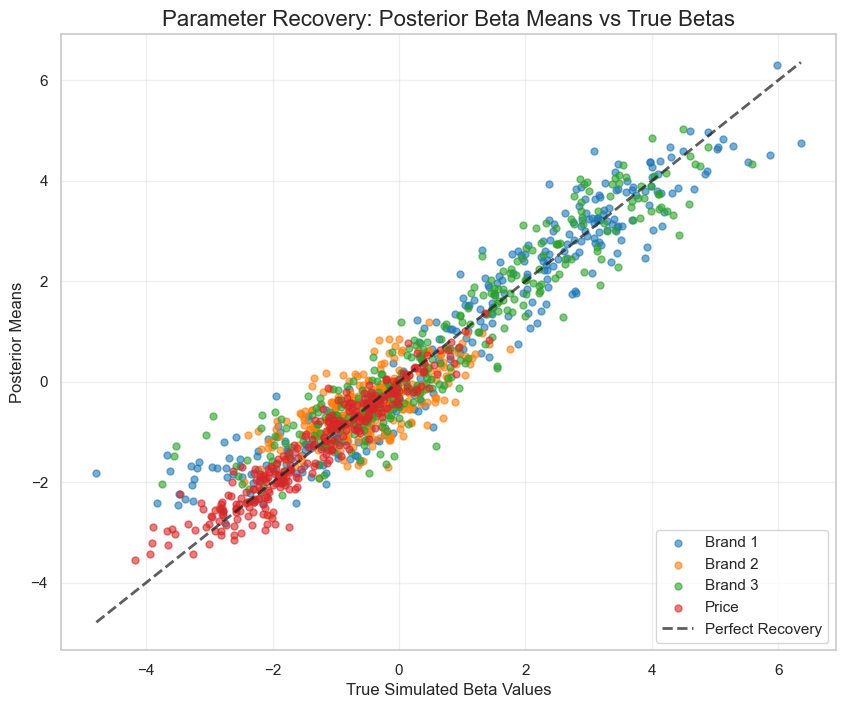


Plotting Household-Level Beta Distributions...


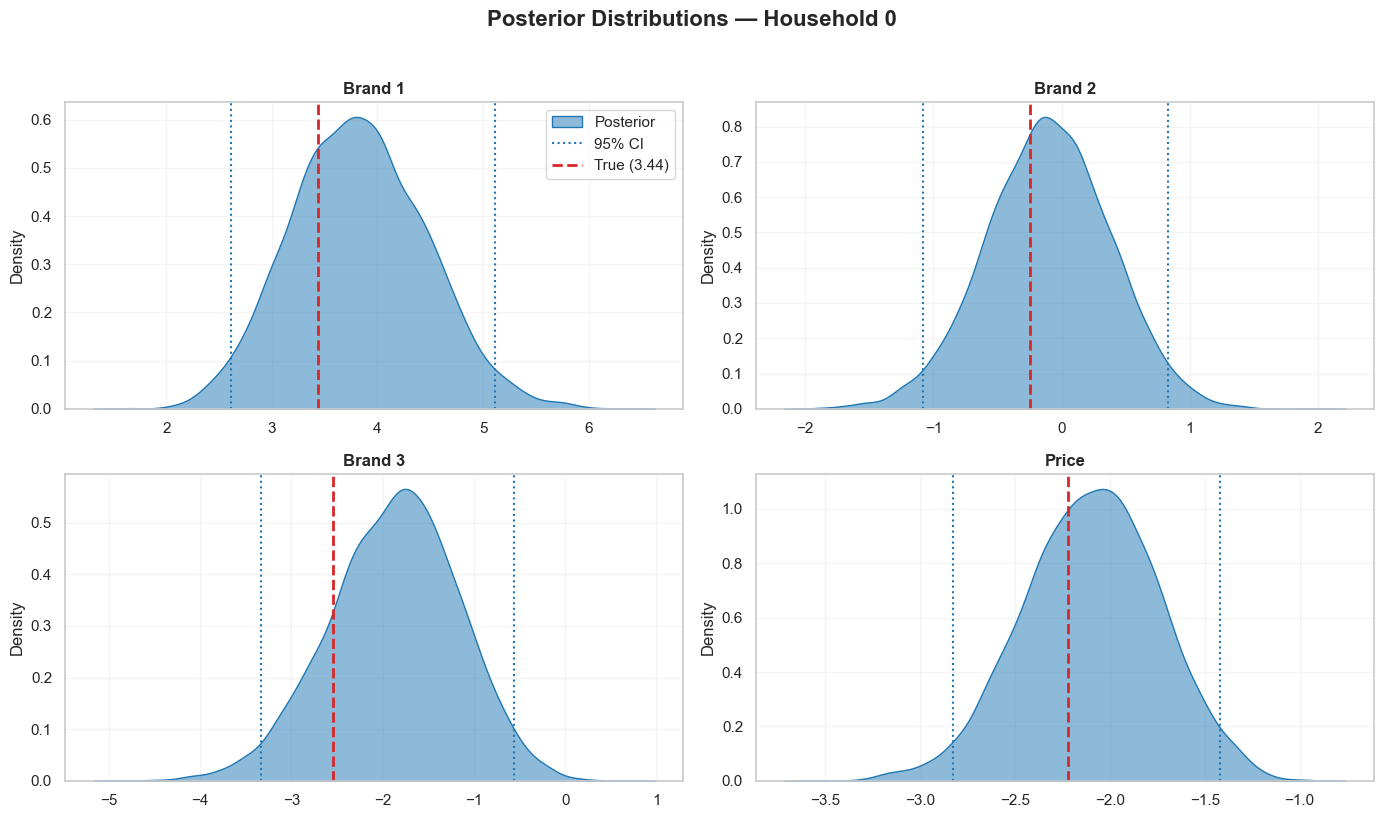

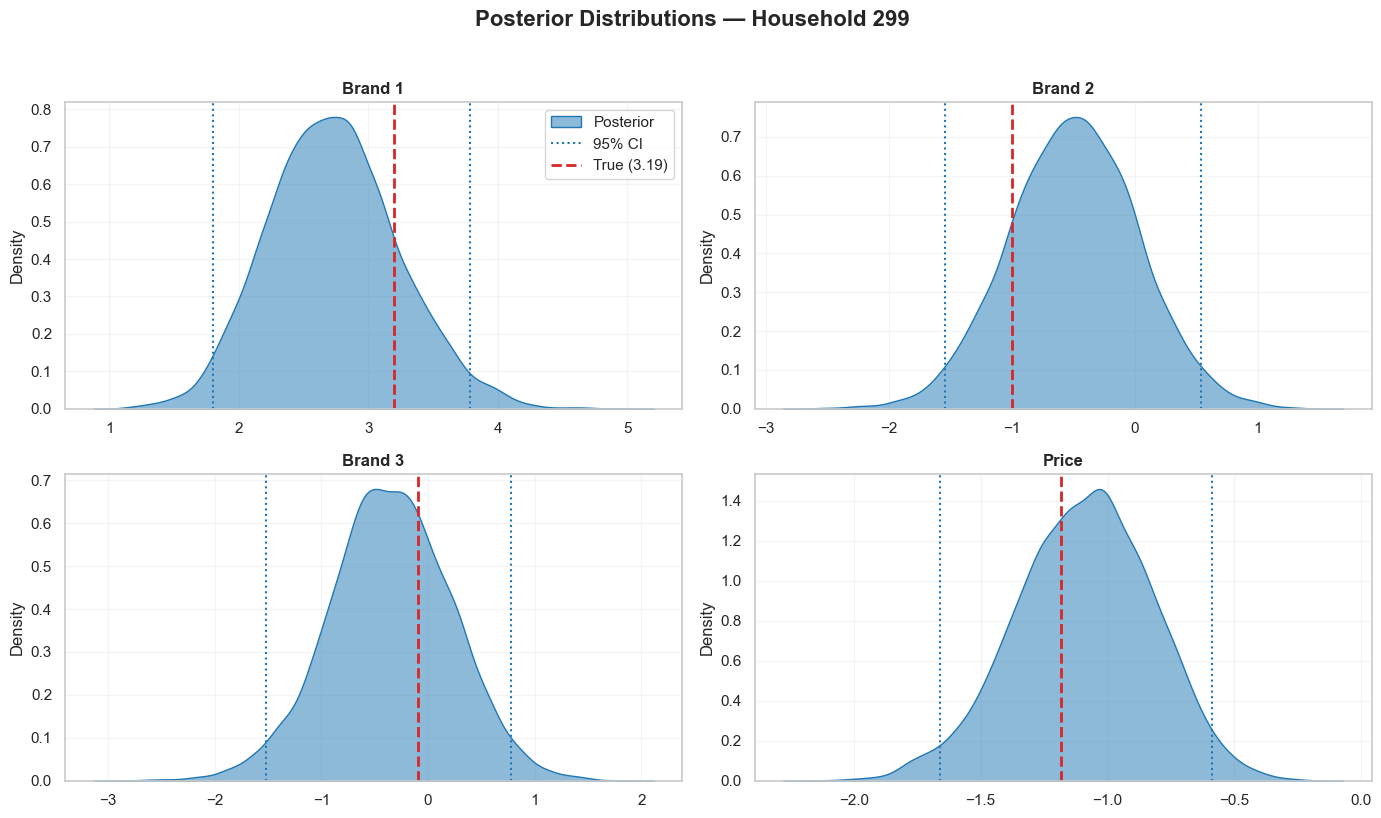

In [28]:
# ==========================================
# 11. HOUSEHOLD BETA RECOVERY
# ==========================================

n_chains, n_draws, n_units, n_params_b = posterior_samples["beta_i"].shape
liesel_beta_full = posterior_samples["beta_i"].reshape(-1, n_units, n_params_b)
true_betas_full  = choice_data["TRUE_BETA"]
l_beta_means     = np.mean(liesel_beta_full, axis=0)

# Scatter: posterior means vs true values, coloured by true segment
fig, ax = plt.subplots(figsize=(10, 8))
colors_params = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, param in enumerate(param_names):
    ax.scatter(true_betas_full[:, i], l_beta_means[:, i],
               alpha=0.6, s=25, label=param, color=colors_params[i])

min_val = min(true_betas_full.min(), l_beta_means.min())
max_val = max(true_betas_full.max(), l_beta_means.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'k--', lw=2, alpha=0.7, label='Perfect Recovery')

ax.set_title("Parameter Recovery: Posterior Beta Means vs True Betas", fontsize=16)
ax.set_xlabel("True Simulated Beta Values", fontsize=12)
ax.set_ylabel("Posterior Means", fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()


# Household-level posterior distributions
def plot_beta_distributions(samples, true_vals, p_names, title_prefix,
                             color_l="#1f77b4", color_t="#d62728"):
    cols = 2
    rows = int(np.ceil(len(p_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))

    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis('off')
            continue

        l_vals          = samples[:, i]
        t_val           = true_vals[i]
        ci_low, ci_high = np.percentile(l_vals, [2.5, 97.5])

        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l,
                    alpha=0.5, label="Posterior")
        ax.axvline(ci_low,  color=color_l, linestyle=":", lw=1.5, label="95% CI")
        ax.axvline(ci_high, color=color_l, linestyle=":", lw=1.5)
        ax.axvline(t_val,   color=color_t, linestyle="--", lw=2,
                   label=f"True ({t_val:.2f})")

        ax.set_title(param, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for idx, (h, l) in
                      enumerate(zip(handles, labels)) if l not in labels[:idx]]
            ax.legend(*zip(*unique), loc="upper right")

    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("\nPlotting Household-Level Beta Distributions...")
plot_beta_distributions(liesel_beta_full[:, 0, :],  true_betas_full[0, :],
                        param_names, "Posterior Distributions — Household 0")
plot_beta_distributions(liesel_beta_full[:, -1, :], true_betas_full[-1, :],
                        param_names, f"Posterior Distributions — Household {n_units-1}")

In [29]:
# ==========================================
# POST-HOC LABEL SWITCHING CORRECTION
# ==========================================

def relabel_posterior_samples(posterior_samples, K,
                               pivot_demo=0, pivot_param=0):
    """
    Fixes label switching via a post-hoc ordering constraint.

    For each draw, reorders the K component indices so that
    Delta[k, pivot_demo, pivot_param] is strictly ascending across k.

    This selects one of the K! symmetric posterior modes and maps
    all draws into it, making cross-chain comparisons meaningful.

    Args:
        posterior_samples : dict of raw posterior arrays from Goose
        K                 : number of mixture components
        pivot_demo        : demographic index used as the ordering pivot
        pivot_param       : parameter index used as the ordering pivot
                            (default: 0 = Brand 1 intercept, most separated)

    Returns:
        dict with the same keys but component axes relabeled per-draw.
        Shape conventions:
          Delta                  : (total_draws, K, n_demos, n_params)
          sigma_inv_chol_latent  : (total_draws, K, n_latent)
          w_logits               : (total_draws, K)
          beta_i                 : (total_draws, n_units, n_params)  -- unchanged
    """
    # --- Extract raw arrays and flatten chains × draws ---
    delta  = np.array(posterior_samples["Delta"])                 # (C, D, K, demos, params)
    sigma  = np.array(posterior_samples["sigma_inv_chol_latent"]) # (C, D, K, n_latent)
    logits = np.array(posterior_samples["w_logits"])              # (C, D, K)
    beta   = np.array(posterior_samples["beta_i"])                # (C, D, units, params)

    C, D, K_actual, n_demos, n_params_d = delta.shape

    delta_f  = delta.reshape(-1, K_actual, n_demos, n_params_d)   # (N, K, demos, params)
    sigma_f  = sigma.reshape(-1, K_actual, sigma.shape[-1])        # (N, K, latent)
    logits_f = logits.reshape(-1, K_actual)                        # (N, K)
    beta_f   = beta.reshape(-1, *beta.shape[2:])                   # (N, units, params)

    N = delta_f.shape[0]

    # --- Compute ordering permutation for each draw ---
    # pivot_vals[i, k] = Delta value of component k for draw i
    pivot_vals = delta_f[:, :, pivot_demo, pivot_param]            # (N, K)
    # argsort gives the permutation that sorts ascending
    perms = np.argsort(pivot_vals, axis=1)                         # (N, K)

    # --- Apply permutations consistently across all component-indexed arrays ---
    # Using advanced indexing: for draw i, reorder axis-1 by perms[i]
    row_idx = np.arange(N)[:, None]                                # (N, 1)

    delta_rl  = delta_f[row_idx, perms]                            # (N, K, demos, params)
    sigma_rl  = sigma_f[row_idx, perms]                            # (N, K, latent)
    logits_rl = logits_f[row_idx, perms]                           # (N, K)

    return {
        "Delta":                 delta_rl,
        "sigma_inv_chol_latent": sigma_rl,
        "w_logits":              logits_rl,
        "beta_i":                beta_f,    # no K dimension — unchanged
    }


# Apply the correction
# pivot_param=0 = Brand 1 intercept, the most separated parameter in your simulation
# Component with lower Brand 1 intercept will always be labelled Component 0
print("Applying post-hoc label switching correction...")
relabeled_samples = relabel_posterior_samples(
    posterior_samples, K=K_COMPONENTS,
    pivot_demo=0, pivot_param=0
)

print(f"Relabeled Delta shape  : {relabeled_samples['Delta'].shape}")
print(f"Relabeled Pi    shape  : {relabeled_samples['w_logits'].shape}")

Applying post-hoc label switching correction...
Relabeled Delta shape  : (8000, 2, 2, 4)
Relabeled Pi    shape  : (8000, 2)


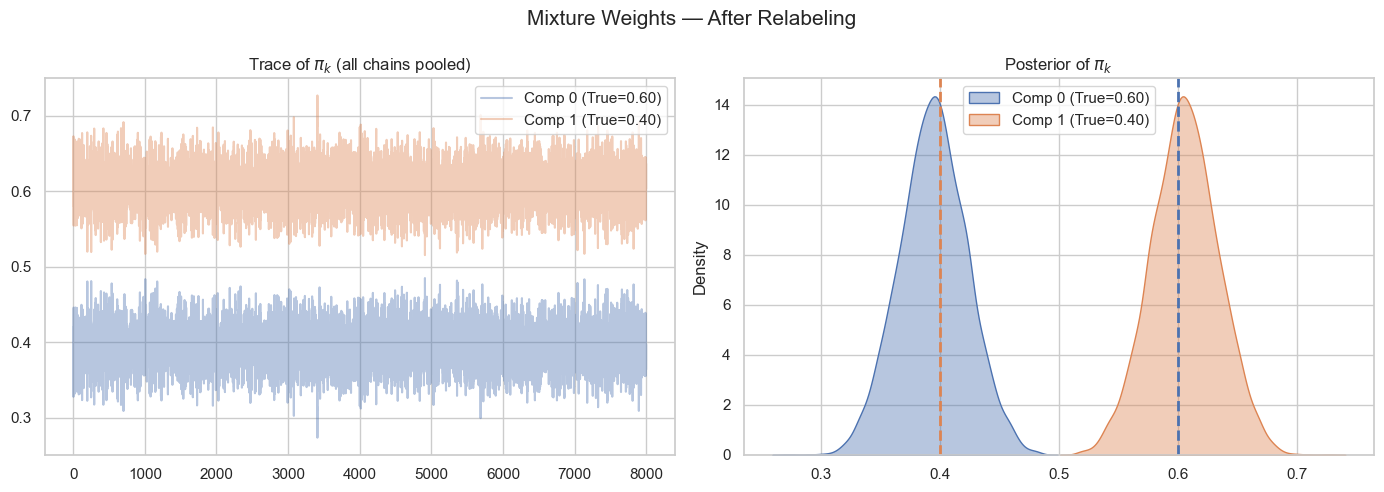


=== Delta Recovery After Relabeling ===

--- Component 0 ---
True Delta:


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),2.5,-0.5,-0.5,-2.0
Demographic 1,0.8,-0.3,0.0,0.5


Posterior Delta [mean (std)]:


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),-1.33 (0.16),-0.54 (0.14),2.69 (0.13),-0.37 (0.07)
Demographic 1,-0.34 (0.16),0.36 (0.15),0.55 (0.15),-0.06 (0.08)


|True − Posterior Mean|:


...

,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),-1.5,-0.5,2.5,-0.5
Demographic 1,-0.5,0.2,0.5,-0.1


Posterior Delta [mean (std)]:


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),2.61 (0.10),-0.40 (0.08),-0.42 (0.11),-1.97 (0.07)
Demographic 1,0.83 (0.10),-0.18 (0.09),-0.01 (0.11),0.47 (0.06)


|True − Posterior Mean|:


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),4.115,0.104,2.917,1.474
Demographic 1,1.329,0.378,0.515,0.572


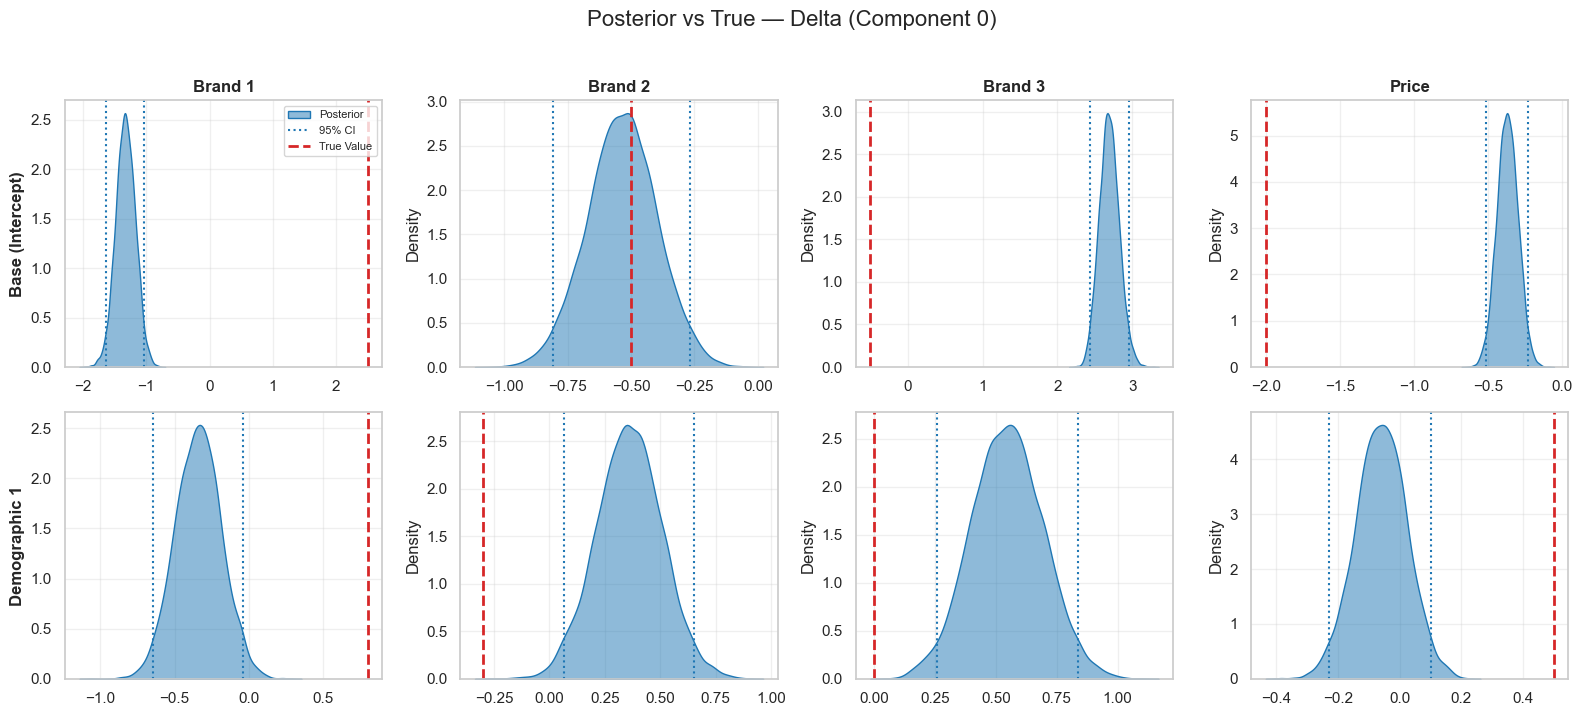

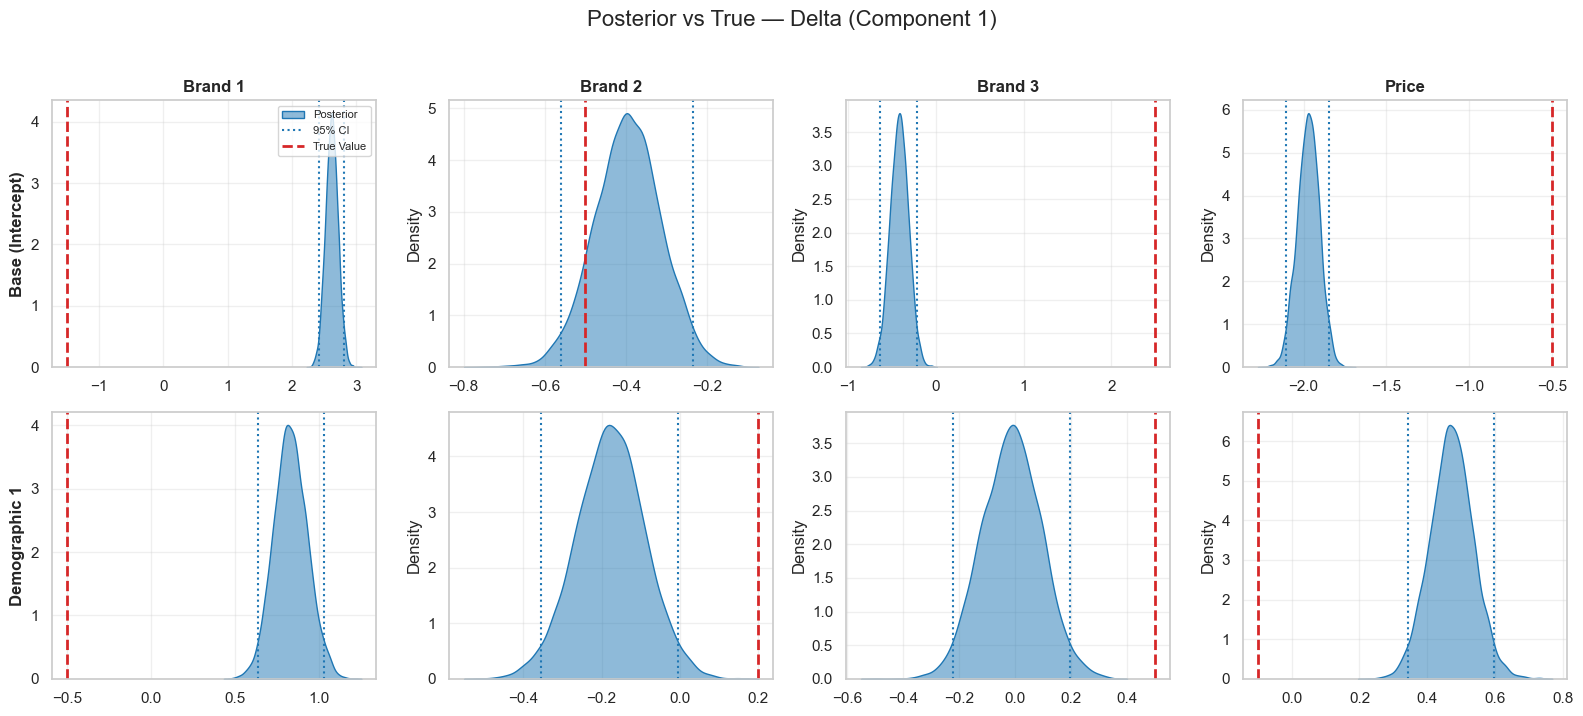

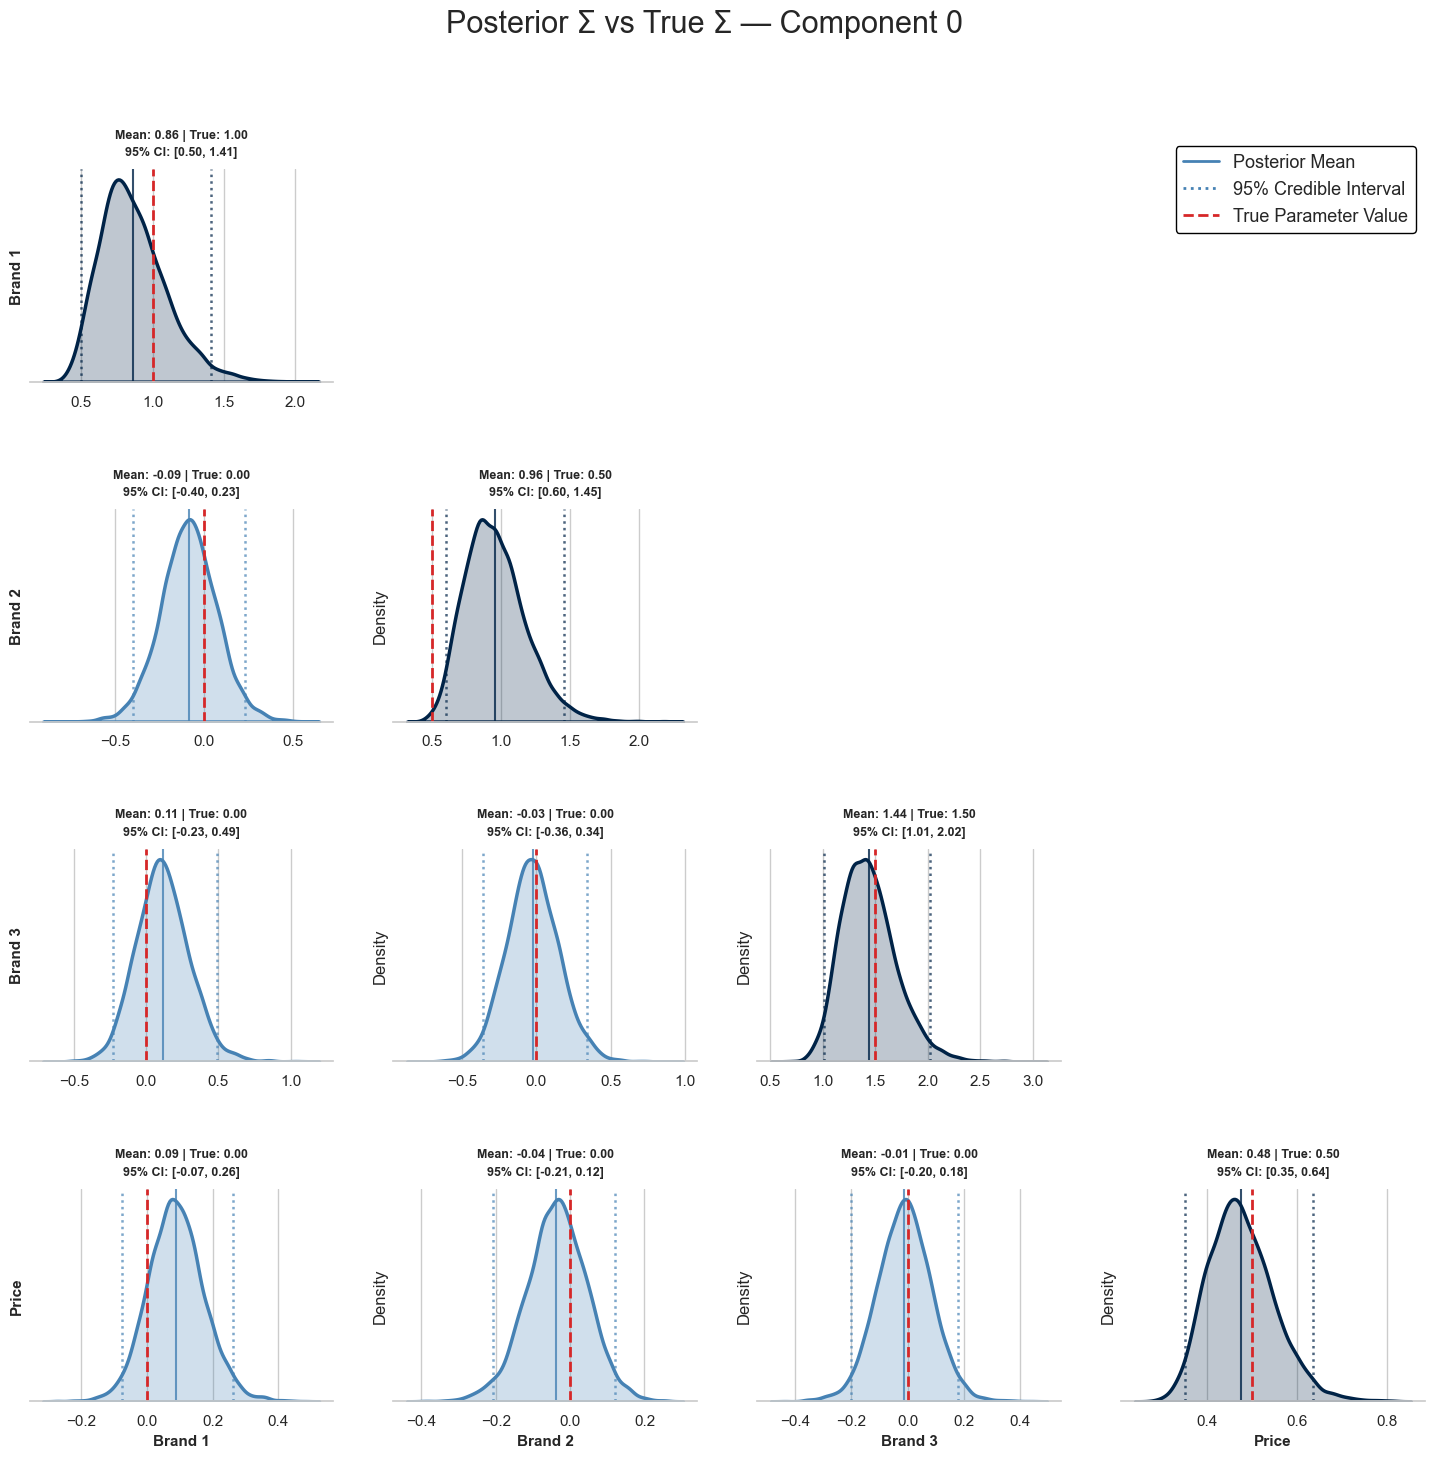

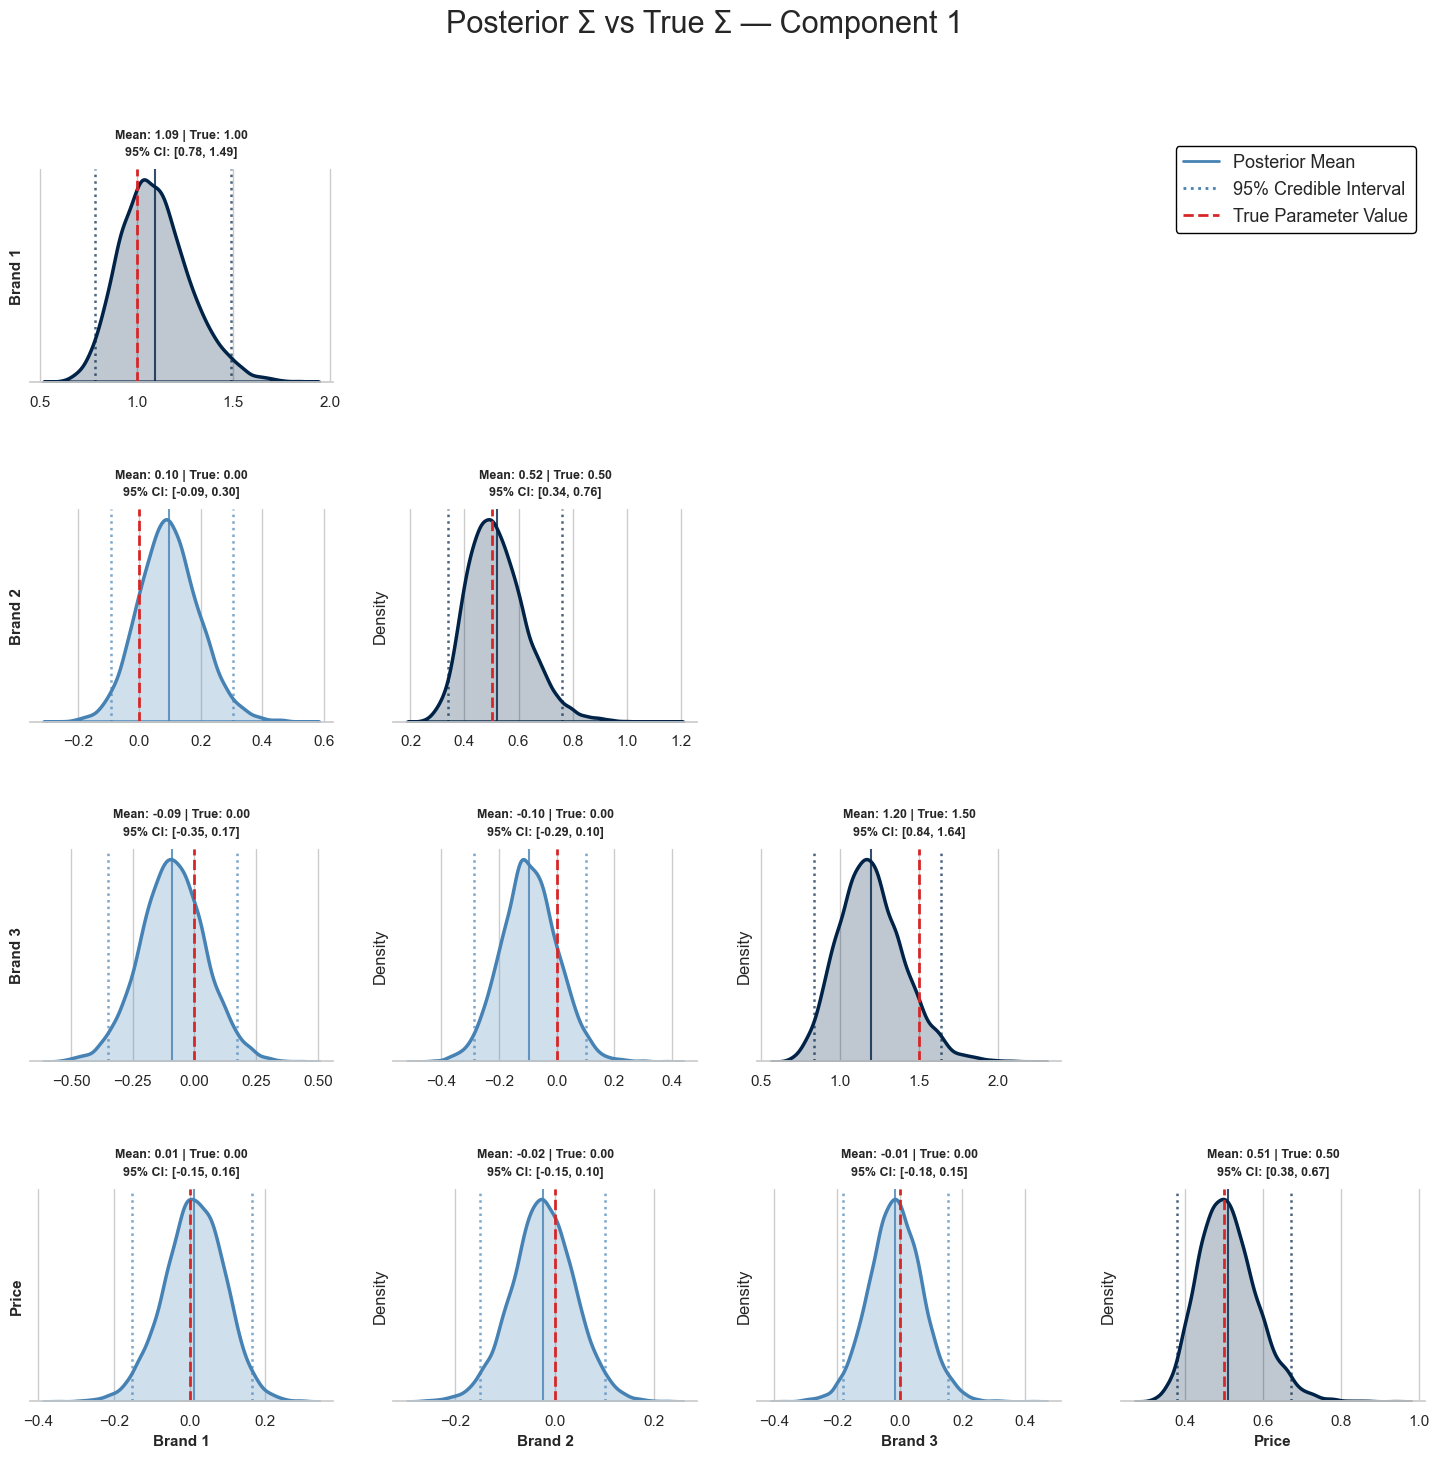

In [30]:
# ==========================================
# RE-RUN DIAGNOSTICS ON RELABELED SAMPLES
# ==========================================

rs = relabeled_samples  # shorthand

# --- Mixture weights ---
pi_rl = jax.nn.softmax(rs["w_logits"], axis=-1)   # (total_draws, K)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mixture Weights — After Relabeling", fontsize=15)

for k in range(K_COMPONENTS):
    # Trace (using draw index as proxy for iteration)
    axes[0].plot(pi_rl[:, k], color=f"C{k}", alpha=0.4,
                 label=f"Comp {k} (True={choice_data['TRUE_PI'][k]:.2f})")
    # Density
    true_pi = choice_data["TRUE_PI"][k]
    sns.kdeplot(pi_rl[:, k], ax=axes[1], fill=True,
                color=f"C{k}", alpha=0.4,
                label=f"Comp {k} (True={true_pi:.2f})")
    axes[1].axvline(true_pi, color=f"C{k}", linestyle="--", lw=2)

axes[0].set_title("Trace of $\\pi_k$ (all chains pooled)"); axes[0].legend()
axes[1].set_title("Posterior of $\\pi_k$");               axes[1].legend()
plt.tight_layout(); plt.show()


# --- Delta summary tables (now using relabeled_samples) ---
delta_rl_flat = rs["Delta"]   # (total_draws, K, demos, params)

print("\n=== Delta Recovery After Relabeling ===")
for k in range(K_COMPONENTS):
    true_delta_k = choice_data["TRUE_DELTA"][k]
    print(f"\n--- Component {k} ---")
    print("True Delta:")
    display(pd.DataFrame(true_delta_k, index=demo_names, columns=param_names))
    print("Posterior Delta [mean (std)]:")
    display(generate_delta_table_mixture(delta_rl_flat, k, param_names, demo_names))
    print("|True − Posterior Mean|:")
    display(generate_delta_diff_table_mixture(
        true_delta_k, delta_rl_flat, k, param_names, demo_names))


# --- Delta posterior distributions ---
plot_delta_distributions_mixture(
    delta_rl_flat, choice_data["TRUE_DELTA"],
    param_names, demo_names, K_COMPONENTS
)

# --- Covariance recovery ---
sigma_rl = v_latent_to_sigma(
    rs["sigma_inv_chol_latent"].reshape(
        *posterior_samples["sigma_inv_chol_latent"].shape[:2],
        K_COMPONENTS, -1
    )
).reshape(-1, K_COMPONENTS, n_params, n_params)

plot_covariance_mixture(sigma_rl, choice_data["TRUE_SIGMA"], K_COMPONENTS, param_names)

In [31]:
def relabel_posterior_samples(posterior_samples, K,
                               pivot_demo=0, pivot_param=0,
                               ascending=False):          # <-- NEW: default descending
    """
    Post-hoc label switching correction via ordering constraint.

    ascending=False  → component with HIGHEST pivot value gets label 0
                       (matches simulation: true Comp 0 has Brand1=+2.5)
    ascending=True   → component with LOWEST pivot value gets label 0
    
    Correct pivot choice is critical: pick the parameter with the largest
    separation between components. In your simulation, Brand 1 intercept
    separates cleanly: +2.5 vs -1.5.
    """
    delta  = np.array(posterior_samples["Delta"])
    sigma  = np.array(posterior_samples["sigma_inv_chol_latent"])
    logits = np.array(posterior_samples["w_logits"])
    beta   = np.array(posterior_samples["beta_i"])

    C, D, K_actual, n_demos, n_params_d = delta.shape

    delta_f  = delta.reshape(-1, K_actual, n_demos, n_params_d)
    sigma_f  = sigma.reshape(-1, K_actual, sigma.shape[-1])
    logits_f = logits.reshape(-1, K_actual)
    beta_f   = beta.reshape(-1, *beta.shape[2:])

    N = delta_f.shape[0]

    pivot_vals = delta_f[:, :, pivot_demo, pivot_param]  # (N, K)
    perms      = np.argsort(pivot_vals, axis=1)           # ascending
    
    if not ascending:
        perms = perms[:, ::-1]                            # flip → descending
    
    row_idx = np.arange(N)[:, None]

    return {
        "Delta":                 delta_f[row_idx, perms],
        "sigma_inv_chol_latent": sigma_f[row_idx, perms],
        "w_logits":              logits_f[row_idx, perms],
        "beta_i":                beta_f,
    }


# ---------------------------------------------------------------
# Quick sanity check BEFORE running all plots
# ---------------------------------------------------------------
def check_relabeling(relabeled_samples, true_delta_all, K,
                     pivot_demo=0, pivot_param=0):
    """
    Prints posterior mean of the pivot parameter per component
    alongside the true values, so you can confirm alignment
    before producing all downstream plots.
    """
    delta_rl = relabeled_samples["Delta"]   # (N, K, demos, params)
    print("\n=== Relabeling Sanity Check (pivot parameter) ===")
    print(f"{'Component':<12} {'Post. Mean':>12} {'True Value':>12} {'Match?':>8}")
    print("-" * 48)
    for k in range(K):
        post_mean = np.mean(delta_rl[:, k, pivot_demo, pivot_param])
        true_val  = true_delta_all[k, pivot_demo, pivot_param]
        # "Match" = posterior mean is closer to this component's true value
        # than to the other component's true value
        dists = [abs(post_mean - true_delta_all[j, pivot_demo, pivot_param])
                 for j in range(K)]
        match = "✓" if np.argmin(dists) == k else "✗  ← still misaligned"
        print(f"  Comp {k}      {post_mean:>12.3f} {true_val:>12.3f} {match:>8}")


relabeled_samples = relabel_posterior_samples(
    posterior_samples, K=K_COMPONENTS,
    pivot_demo=0, pivot_param=0,
    ascending=False   # descending: highest Brand 1 intercept → Component 0
)

check_relabeling(relabeled_samples, choice_data["TRUE_DELTA"],
                 K=K_COMPONENTS, pivot_demo=0, pivot_param=0)


=== Relabeling Sanity Check (pivot parameter) ===
Component      Post. Mean   True Value   Match?
------------------------------------------------
  Comp 0             2.615        2.500        ✓
  Comp 1            -1.331       -1.500        ✓


In [32]:
# Alternative: use the DIFFERENCE between Brand 1 and Brand 3 intercepts
# as an implicit pivot (maximally separating in your simulation)
# Component 0: Brand1=2.5, Brand3=-0.5 → diff = +3.0
# Component 1: Brand1=-1.5, Brand3=2.5 → diff = -4.0
# Ordering by descending diff puts Component 0 first

def relabel_by_contrast(posterior_samples, K,
                         demo=0, param_high=0, param_low=2):
    """
    Orders components by descending (param_high - param_low) contrast.
    More robust than a single pivot when components overlap on any
    single dimension.
    """
    delta  = np.array(posterior_samples["Delta"])
    sigma  = np.array(posterior_samples["sigma_inv_chol_latent"])
    logits = np.array(posterior_samples["w_logits"])
    beta   = np.array(posterior_samples["beta_i"])

    C, D, K_actual, n_demos, n_params_d = delta.shape
    delta_f  = delta.reshape(-1, K_actual, n_demos, n_params_d)
    sigma_f  = sigma.reshape(-1, K_actual, sigma.shape[-1])
    logits_f = logits.reshape(-1, K_actual)
    beta_f   = beta.reshape(-1, *beta.shape[2:])
    N        = delta_f.shape[0]

    contrast = (delta_f[:, :, demo, param_high]
              - delta_f[:, :, demo, param_low])             # (N, K)
    perms    = np.argsort(contrast, axis=1)[:, ::-1]        # descending

    row_idx = np.arange(N)[:, None]
    return {
        "Delta":                 delta_f[row_idx, perms],
        "sigma_inv_chol_latent": sigma_f[row_idx, perms],
        "w_logits":              logits_f[row_idx, perms],
        "beta_i":                beta_f,
    }

relabeled_samples = relabel_by_contrast(
    posterior_samples, K=K_COMPONENTS,
    demo=0, param_high=0, param_low=2  # Brand 1 minus Brand 3
)
check_relabeling(relabeled_samples, choice_data["TRUE_DELTA"],
                 K=K_COMPONENTS, pivot_demo=0, pivot_param=0)


=== Relabeling Sanity Check (pivot parameter) ===
Component      Post. Mean   True Value   Match?
------------------------------------------------
  Comp 0             2.615        2.500        ✓
  Comp 1            -1.331       -1.500        ✓
